In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import pickle
from sklearn.preprocessing import MinMaxScaler



from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (precision_recall_curve, classification_report,
                           ConfusionMatrixDisplay, balanced_accuracy_score,roc_curve,
                           PrecisionRecallDisplay, confusion_matrix,roc_auc_score,RocCurveDisplay)



import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install -q gdown


In [ ]:
import gdown
# Identifiant du fichier
file_id = "1oG5raeNW1HaHXfiadPsIBlva3jVP3Az_"

# Construire l'URL de téléchargement
url = f"https://drive.google.com/uc?id={file_id}"

# Télécharger le fichier
gdown.download(url, output="data.csv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1oG5raeNW1HaHXfiadPsIBlva3jVP3Az_
From (redirected): https://drive.google.com/uc?id=1oG5raeNW1HaHXfiadPsIBlva3jVP3Az_&confirm=t&uuid=ee6bf0b8-c78a-426e-b3eb-deacc028a41c
To: /content/data.csv
100%|██████████| 7.76G/7.76G [01:18<00:00, 98.6MB/s]


'data.csv'

In [4]:
data = pd.read_csv('/content/drive/MyDrive/data.csv') #drive ferieluc
#data = pd.read_csv('data.csv') #any drive

In [5]:
data.shape

(48700314, 28)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48700314 entries, 0 to 48700313
Data columns (total 28 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Length of Fwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Flow IAT Mean                float64
 9   Flow IAT Std                 float64
 10  Flow IAT Max                 float64
 11  Flow IAT Min                 float64
 12  Fwd IAT Total                float64
 13  Fwd IAT Mean                 float64
 14  Fwd IAT Std                  float64
 15  Fwd IAT Max                  float64
 16  Fwd IAT Min                  float64
 17  Fwd Header Length            int64  
 18  Fwd Packets/s                float64
 19

In [7]:
# Afficher les valeurs uniques et leur nombre
print(data["Label"].value_counts())

Label
1    48643451
0       56863
Name: count, dtype: int64


# Matrice de corrélation sur toutes les données

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice de corrélation sur toutes les données
corr_matrix = data.corr()

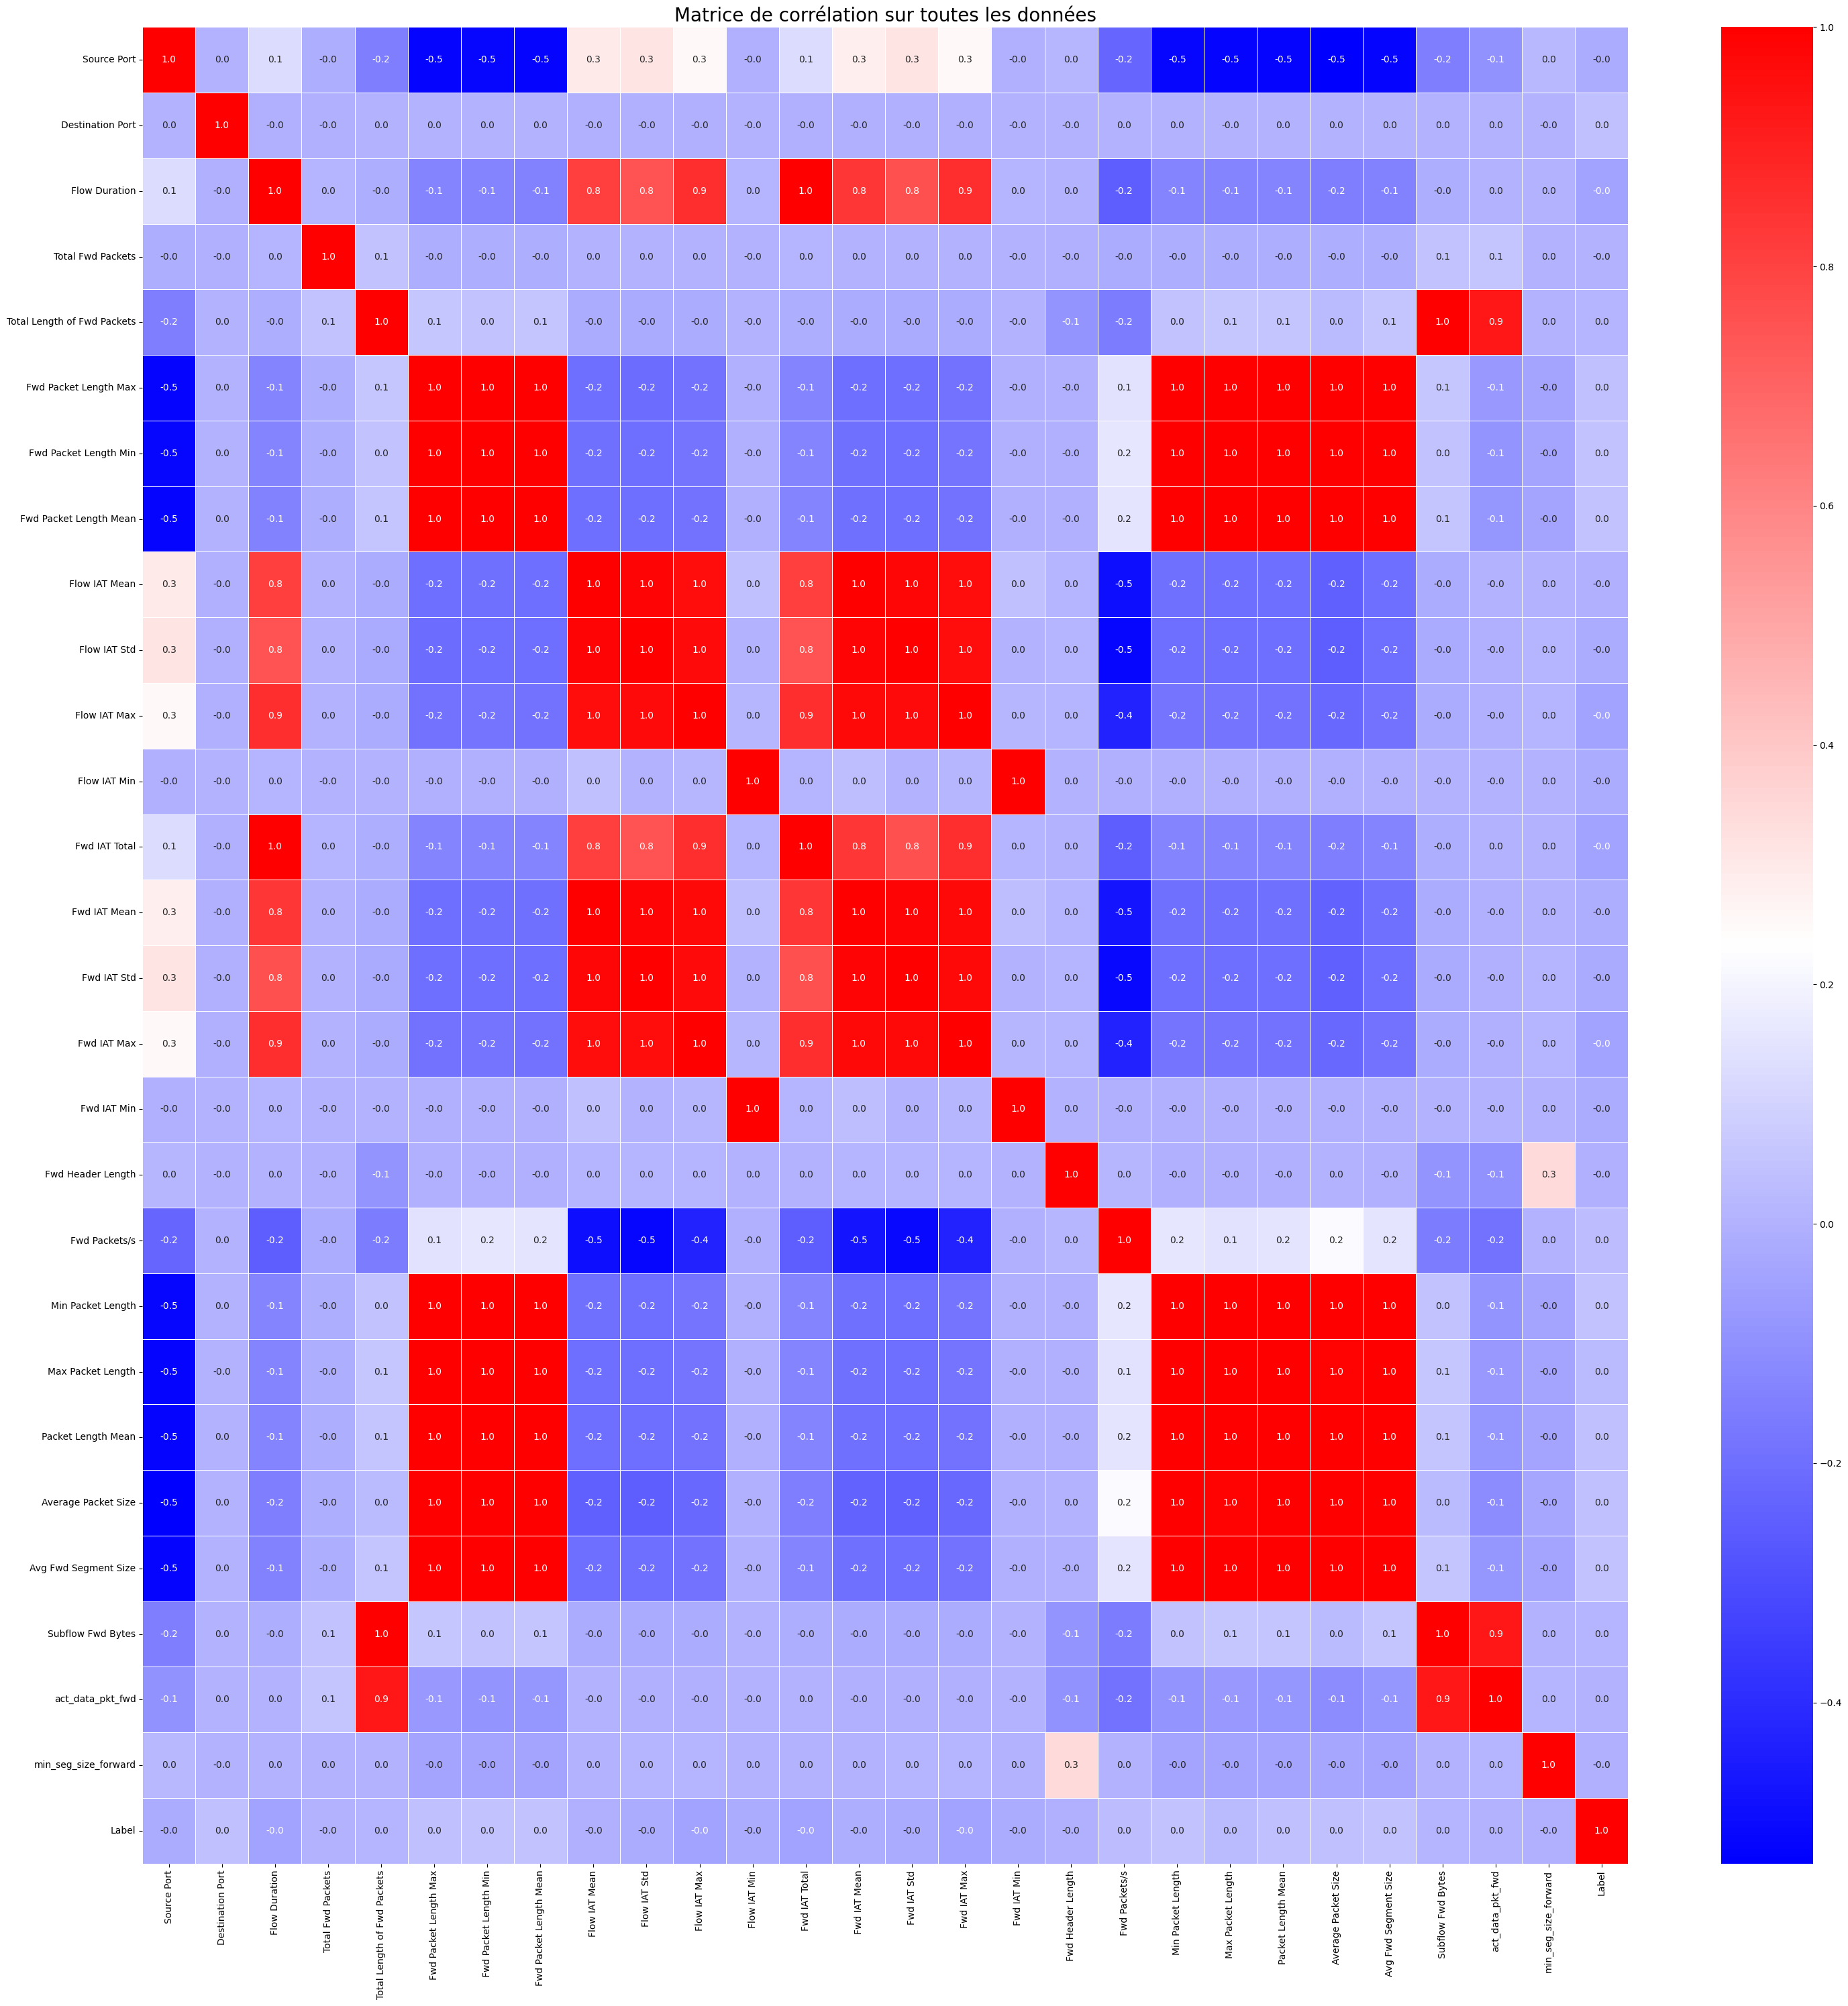

In [ ]:
# Affichage de la heatmap
plt.figure(figsize=(30, 30 ))  # Ajuste selon la densité souhaitée
sns.heatmap(corr_matrix, cmap='bwr', annot=True, fmt=".1f", linewidths=0.5)
plt.title("Matrice de corrélation sur toutes les données", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_v2.png', dpi=300, bbox_inches='tight')
plt.show()

# Separation train test

In [11]:
# Séparation avec 70% train / 30% test
X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 30% pour le test
    random_state=42,  # Reproductibilité
    stratify=y  # Maintient la proportion Attack/BENIGN dans les deux sets
)


In [ ]:
print("Taille totale :", len(data))
print("Train set :", len(X_train), "| Test set :", len(X_test))
print("\nProportion 'BENIGN' (0) dans y_train :", y_train.mean())
print("Proportion 'BENIGN' (0) dans y_test :", y_test.mean())


Taille totale : 48700314
Train set : 34090219 | Test set : 14610095

Proportion 'BENIGN' (0) dans y_train : 0.9988323923645078
Proportion 'BENIGN' (0) dans y_test : 0.9988323826778676


In [ ]:
print("\nDistribution des labels dans y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution des labels dans y_test:")
print(y_test.value_counts(normalize=True))


Distribution des labels dans y_train:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64

Distribution des labels dans y_test:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64


In [ ]:
X_train.info()
X_test.info()
y_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34090219 entries, 16135442 to 36912278
Data columns (total 27 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Length of Fwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Flow IAT Mean                float64
 9   Flow IAT Std                 float64
 10  Flow IAT Max                 float64
 11  Flow IAT Min                 float64
 12  Fwd IAT Total                float64
 13  Fwd IAT Mean                 float64
 14  Fwd IAT Std                  float64
 15  Fwd IAT Max                  float64
 16  Fwd IAT Min                  float64
 17  Fwd Header Length            int64  
 18  Fwd Packets/s                float64
 

# Feature scaling

In [ ]:
# Comparaison des max entre train et test
print("Max (Train):", X_train.max())
print("Max (Test):", X_test.max())

Max (Train): Source Port                    6.553400e+04
Destination Port               6.553500e+04
Flow Duration                  1.200000e+08
Total Fwd Packets              1.001480e+05
Total Length of Fwd Packets    1.526642e+07
Fwd Packet Length Max          3.212000e+04
Fwd Packet Length Min          2.020000e+03
Fwd Packet Length Mean         3.015291e+03
Flow IAT Mean                  6.553614e+07
Flow IAT Std                   6.736895e+07
Flow IAT Max                   1.199544e+08
Flow IAT Min                   6.553614e+07
Fwd IAT Total                  1.200000e+08
Fwd IAT Mean                   6.553614e+07
Fwd IAT Std                    6.736895e+07
Fwd IAT Max                    1.199544e+08
Fwd IAT Min                    6.553614e+07
Fwd Header Length              1.559380e+05
Fwd Packets/s                  4.000000e+06
Min Packet Length              1.472000e+03
Max Packet Length              3.796000e+04
Packet Length Mean             4.023945e+03
Average Packet Size

In [ ]:
# Colonnes où le test dépasse le train
test_higher = X_test.max() > X_train.max()
print("Colonnes avec max(test) > max(train):\n", test_higher[test_higher].index.tolist())

Colonnes avec max(test) > max(train):
 ['Fwd Packet Length Min', 'Flow IAT Std']


In [12]:
# Colonnes problématiques
problem_cols = ['Fwd Packet Length Min', 'Flow IAT Std']

# 1. Calculer les min/max globaux (train + test)
global_min = np.minimum(X_train.min(), X_test.min())
global_max = np.maximum(X_train.max(), X_test.max())

# 2. Initialiser le MinMaxScaler avec ces valeurs
scaler = MinMaxScaler()
scaler.fit(X_train)  # Initialisation standard

# 3. Forcer les min/max globaux pour les colonnes problématiques
scaler.data_min_[X_train.columns.get_indexer(problem_cols)] = global_min[problem_cols].values
scaler.data_max_[X_train.columns.get_indexer(problem_cols)] = global_max[problem_cols].values

# 4. Normalisation
X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [13]:
# Correction finale (au cas où)
X_test_normalized = np.clip(X_test_normalized, 0.0, 1.0)

# Vérification
print("Test - Valeurs > 1.0 :", np.any(X_test_normalized > 1.0))  # Doit être False
print("Max globaux utilisés :", scaler.data_max_[X_train.columns.get_indexer(problem_cols)])

Test - Valeurs > 1.0 : False
Max globaux utilisés : [2.02100000e+03 6.80829254e+07]


In [ ]:
print("Train - Statistiques après normalisation:")
print(pd.DataFrame(X_train_normalized, columns=X_train.columns).describe())
print("\nTest - Statistiques après normalisation:")
print(pd.DataFrame(X_test_normalized, columns=X_test.columns).describe())

Train - Statistiques après normalisation:
        Source Port  Destination Port  Flow Duration  Total Fwd Packets  \
count  3.409022e+07      3.409022e+07   3.409022e+07       3.409022e+07   
mean   4.968842e-01      5.010200e-01   9.631982e-03       4.087742e-05   
std    4.194827e-01      2.884934e-01   4.655156e-02       2.518893e-03   
min    0.000000e+00      0.000000e+00   0.000000e+00       0.000000e+00   
25%    1.283303e-02      2.516365e-01   8.333333e-09       9.985322e-06   
50%    5.818659e-01      5.011673e-01   1.666667e-08       9.985322e-06   
75%    9.533677e-01      7.510185e-01   9.078833e-04       2.995596e-05   
max    1.000000e+00      1.000000e+00   1.000000e+00       1.000000e+00   

       Total Length of Fwd Packets  Fwd Packet Length Max  \
count                 3.409022e+07           3.409022e+07   
mean                  1.593178e-04           2.128862e-02   
std                   4.424665e-04           1.420118e-02   
min                   0.000000e+00    

In [ ]:
from joblib import dump
# 3. Sauvegarder le scaler dans Drive
scaler_path = 'new_scaler_v2.pkl'  # Chemin personnalisable
dump(scaler, scaler_path)

print(f"✅ Scaler sauvegardé ici : {scaler_path}")

✅ Scaler sauvegardé ici : new_scaler_v2.pkl


# Sampling SMOTE avec Split val

In [14]:
# --- 1. Split supplémentaire pour l'optimisation du seuil ---
X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train_normalized, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
X_train_base.shape

(27272175, 27)

In [ ]:
y_train_base.shape

(27272175,)

In [ ]:
X_val.shape

(6818044, 27)

In [ ]:
y_val.shape

(6818044,)

In [15]:
# --- 2. SMOTE appliqué uniquement sur le train de base ---
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_base, y_train_base)


In [ ]:
X_train_resampled.shape

(54480664, 27)

In [ ]:
y_train_resampled.shape

(54480664,)

In [ ]:
# Avant SMOTE
print("Distribution avant SMOTE :")
print(y_train_base.value_counts())

# Après SMOTE
print("\nDistribution après SMOTE :")
print(pd.Series(y_train_resampled).value_counts())

Distribution avant SMOTE :
Label
1    27240332
0       31843
Name: count, dtype: int64

Distribution après SMOTE :
Label
1    27240332
0    27240332
Name: count, dtype: int64


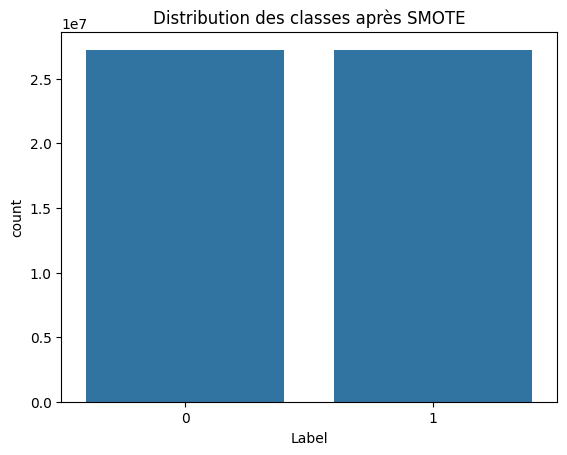

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution après SMOTE
sns.countplot(x=y_train_resampled)
plt.title("Distribution des classes après SMOTE")
plt.show()

In [ ]:
feature_names = X_train.columns.tolist()
print(feature_names)


['Source Port', 'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Average Packet Size', 'Avg Fwd Segment Size', 'Subflow Fwd Bytes', 'act_data_pkt_fwd', 'min_seg_size_forward']


# Random forest smote split val

In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
model = RandomForestClassifier(
    max_depth=5,
    n_estimators=8,
    min_samples_split=50,        # ↑ Seuil de division
    min_samples_leaf=5,
    max_features='sqrt',         # √n features par split
    random_state=42,
    n_jobs=-1,
    verbose=1                    # Affiche la progression

)

In [ ]:
import time

start_train = time.time()
model.fit(X_train_resampled, y_train_resampled)
end_train = time.time()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:  5.8min finished


In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_random_forest_new.pkl')


['modelv1_random_forest_new.pkl']

In [ ]:
import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v1_RF_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv1_random_forest_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")

Modèle sauvegardé et compressé avec succès dans : v1_RF_model_new.zip


In [ ]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
y_proba_val = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:    0.5s finished


In [ ]:
start_pred = time.time()
# --- 5. Évaluation finale sur le test set ---
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
y_pred = (y_pred_prob > optimal_threshold).astype(int)
end_pred = time.time()

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:    0.9s finished


In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE DE DÉTECTION           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")

Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.94      0.89     17059
           1       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.93      0.97      0.95  14610095
weighted avg       1.00      1.00      1.00  14610095

Confusion Matrix :
 [[   15994     1065]
 [    2725 14590311]]


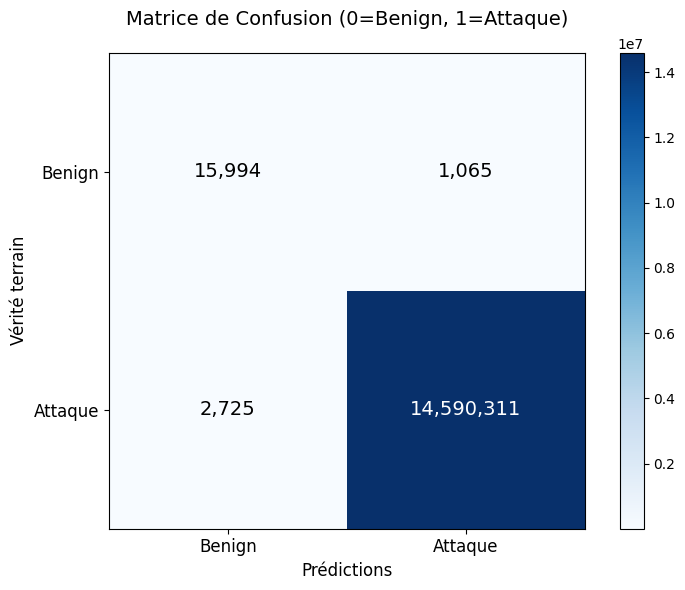

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_RF.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

 - Taux de Faux Positifs (FPR) : 0.0624
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0002



In [ ]:
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")


Temps de prédiction : 2.02 secondes
Temps d'entrainement : 350.63 secondes


In [ ]:
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")

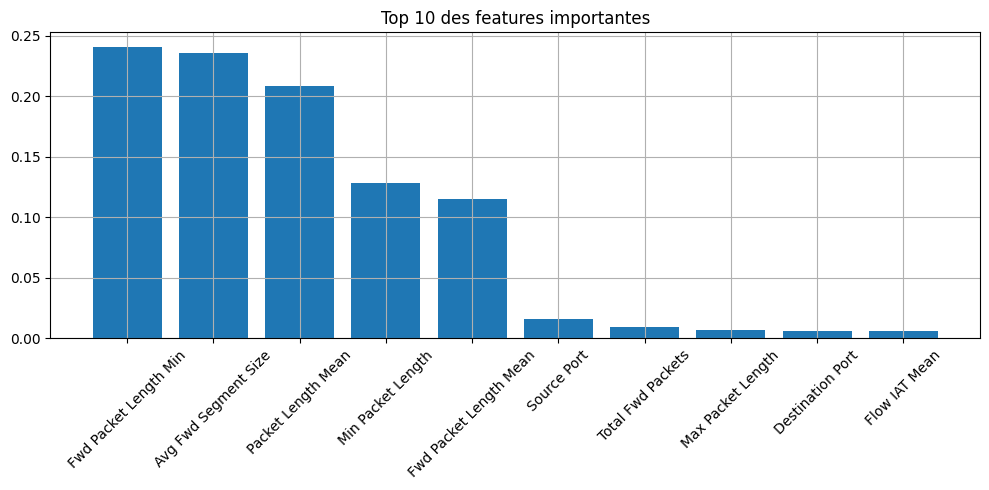

In [ ]:
# 10. Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # top 10
features = X_test.columns[indices]

plt.figure(figsize=(10, 5))
plt.title("Top 10 des features importantes")
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), features, rotation=45)
plt.tight_layout()
plt.grid(True)
plt.savefig("feature_importance.png")
plt.show()


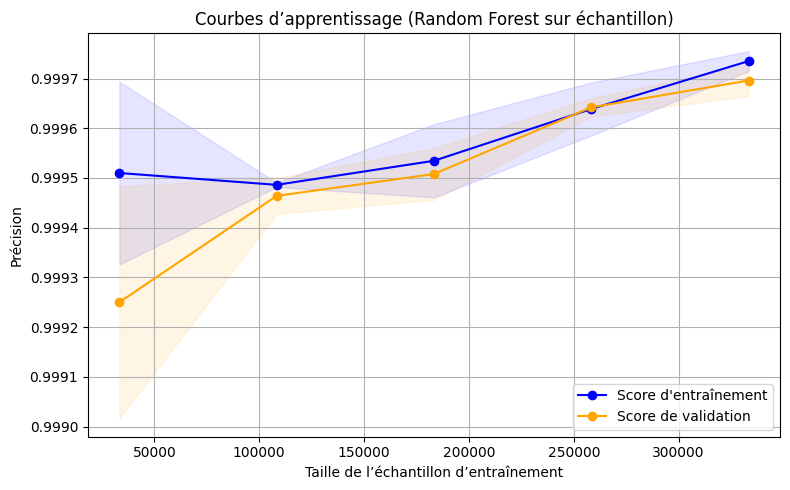

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve.png")
plt.show()


In [8]:
import joblib
modelrf = joblib.load('modelv1_random_forest_new.pkl')

In [9]:
print(type(modelrf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


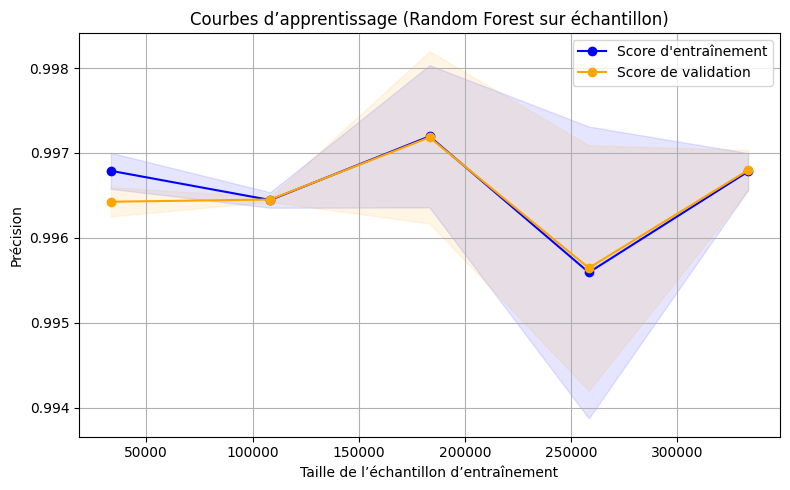

In [16]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_resampled, y_train_resampled, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelrf, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Random Forest sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_rf_v2.png")
plt.show()


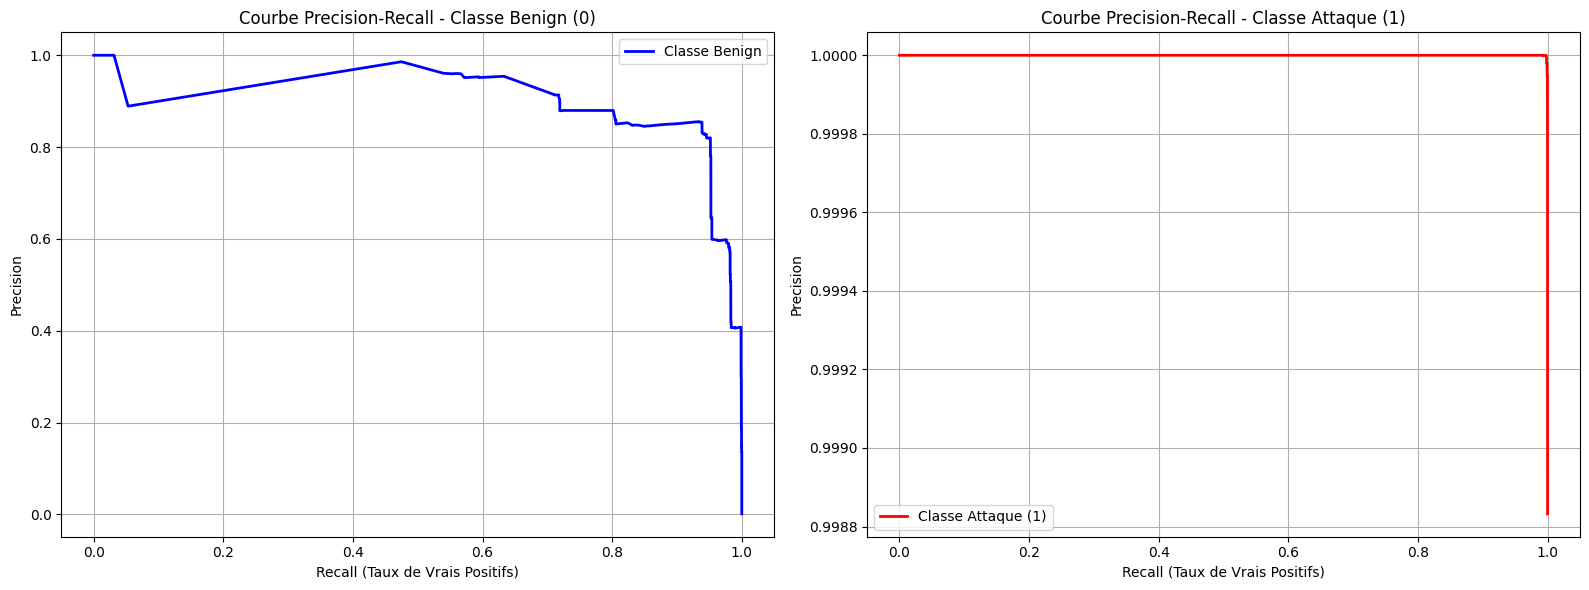

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign (version libre)
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque (version libre)
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# Ajustement automatique
plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1.png")
plt.show()

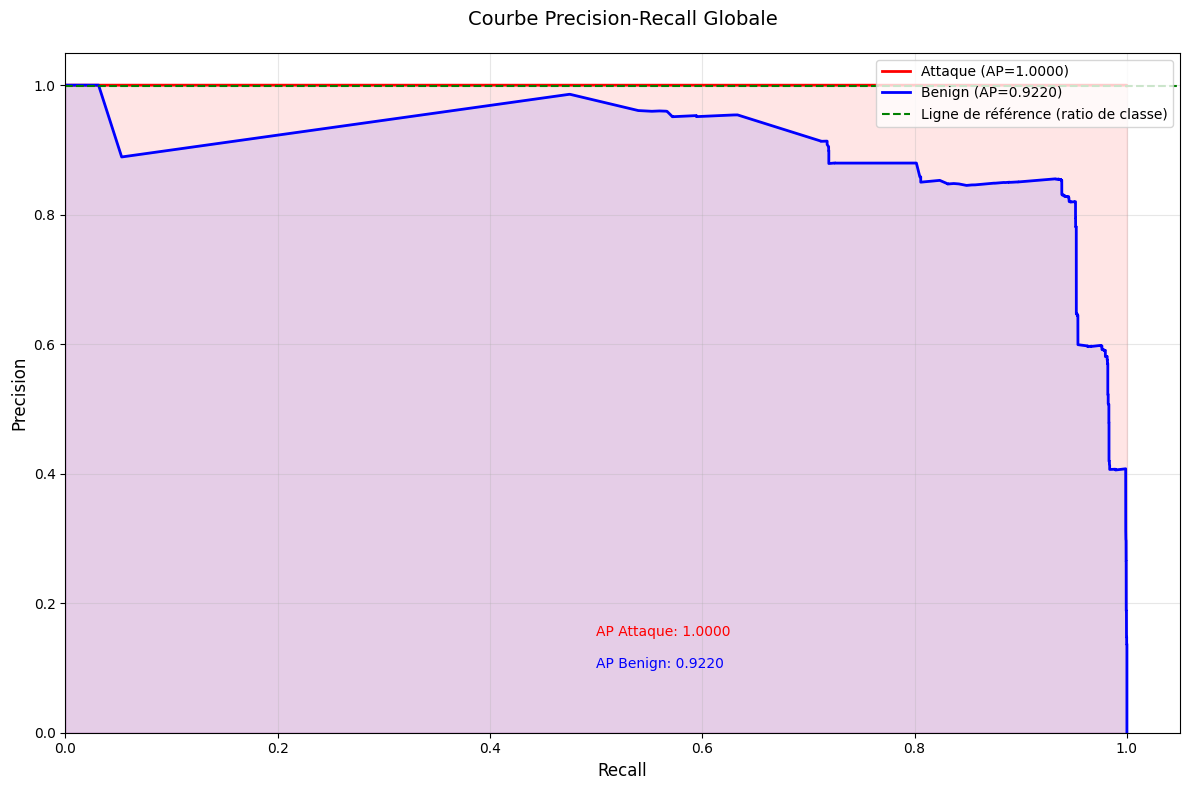

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# 1. Calcul pour les deux classes
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)

# 2. Calcul des Average Precision (AP)
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

# 3. Tracé global
plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

# Ligne de référence
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

# Mise en forme avancée
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Annotations
plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

# Ajout des aires sous courbe
plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global.png")
plt.show()

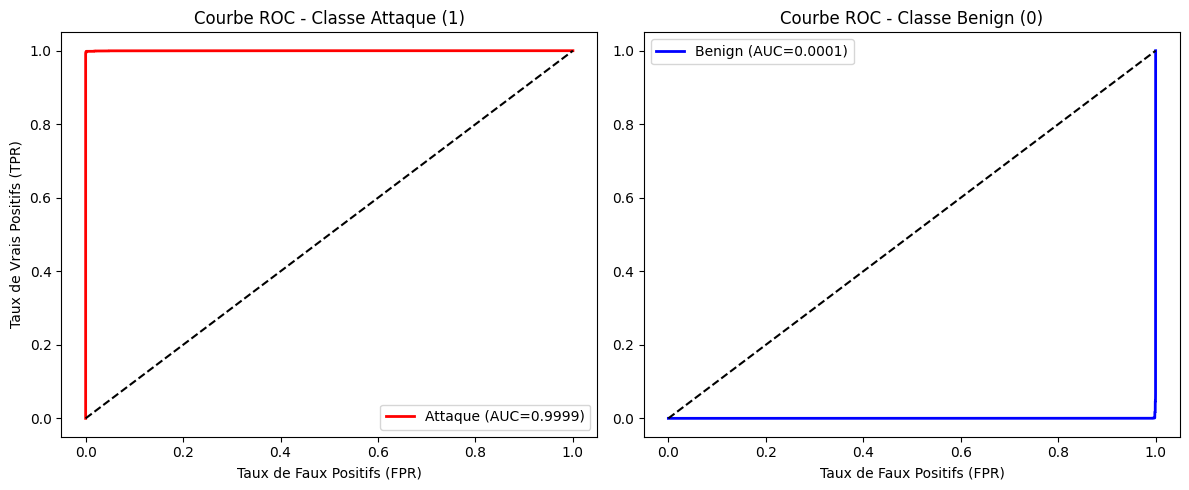

In [ ]:
# 1. Courbe ROC - Classe Attaque (pos_label=1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)  # Pas de pos_label ici

# 2. Courbe ROC - Classe Benign (pos_label=0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)  # Inversion des probabilités

# Tracé
plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1.png")
plt.show()

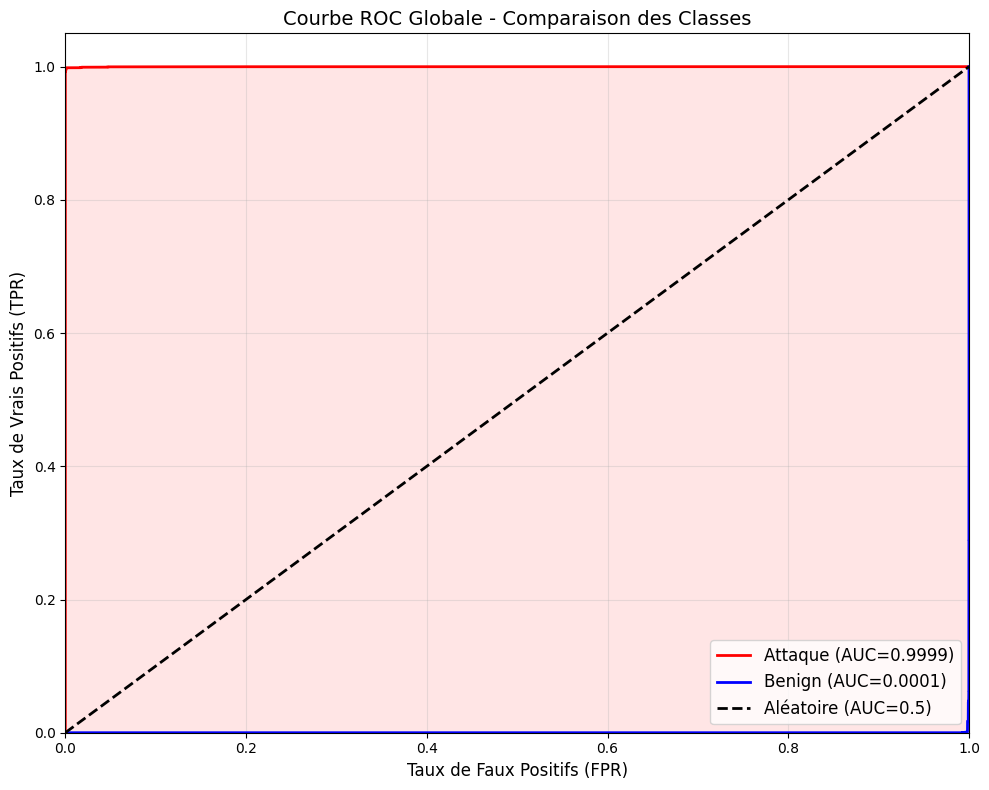

In [ ]:
# 1. Calcul pour la classe Attaque (1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

# 2. Calcul pour la classe Benign (0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

# 3. Tracé global
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

# Mise en forme
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - Comparaison des Classes', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Ajout des zones critiques
plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale.png")
plt.show()

In [ ]:
# Calcul des scores AUC-ROC
auc_attack = roc_auc_score(y_test, y_pred_prob)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)
auc_global = (auc_attack + auc_benign) / 2  # Moyenne macro

# Affichage formaté
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)


══════════════════════════════════════════════════
~~~~~~~~~~~~~ PERFORMANCE DU MODÈLE ~~~~~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.999894
• AUC-ROC Classe Benign (0)  : 0.000106

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Calcul des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

# Affichage formaté
print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE              ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")
# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE              ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")


╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE              ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.8544   ║ 0.9999   ║ 0.9272 ║
║ Recall       ║ 0.9376   ║ 0.9998   ║ 0.9687 ║
║ F1-Score     ║ 0.8941   ║ 0.9999   ║ 0.9470 ║
║ Accuracy     ║          ║          ║ 0.9997 ║
╚══════════════╩══════════╩══════════╩════════╝


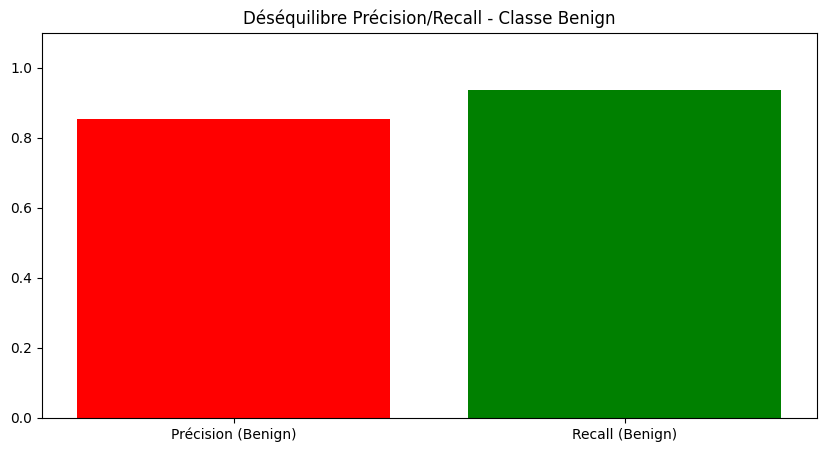

In [ ]:
# Récupération automatique des valeurs depuis le dictionnaire `metrics`
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign')

# Sauvegarde et affichage
plt.savefig("Desequilibre-Precision-Recall-Benign.png")
plt.show()

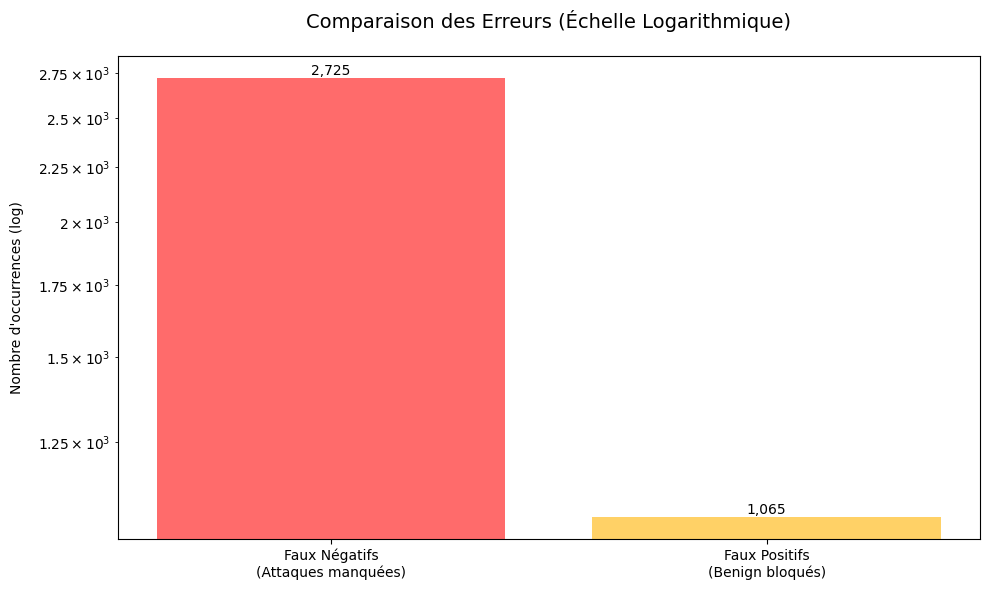

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction automatique depuis la matrice de confusion
TN, FP, FN, TP = cm.ravel()
values = [FN, FP]  # Faux Négatifs, Faux Positifs

# Données du graphique
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Barres avec échelle log pour voir les FP
bars = ax.bar(labels, values, color=colors, log=True)

# Ajout des valeurs exactes sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# Mise en forme
ax.set_title('Comparaison des Erreurs (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel('Nombre d\'occurrences (log)', labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP.png")
plt.show()

# XGBoost

In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 MB 3.4 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier

In [ ]:
model = XGBClassifier(
    max_depth=5,
    n_estimators=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
)

In [ ]:
import time

start_train = time.time()
model.fit(X_train_resampled, y_train_resampled)
end_train = time.time()


In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_xgboost_new.pkl')

['modelv1_xgboost_new.pkl']

In [ ]:
import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v1_XGB_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv1_xgboost_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle sauvegardé et compressé avec succès dans : v1_XGB_model_new.zip


In [ ]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
y_proba_val = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

In [ ]:
start_pred = time.time()
# --- 5. Évaluation finale sur le test set ---
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
y_pred = (y_pred_prob > optimal_threshold).astype(int)
end_pred = time.time()


In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_xgboost.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE XGBOOST           \n")
    f.write("═"*60 + "\n\n")


In [ ]:
# Évaluer
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")


Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.99      0.93     17059
           1       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.94      1.00      0.97  14610095
weighted avg       1.00      1.00      1.00  14610095

Confusion Matrix :
 [[   16915      144]
 [    2354 14590682]]


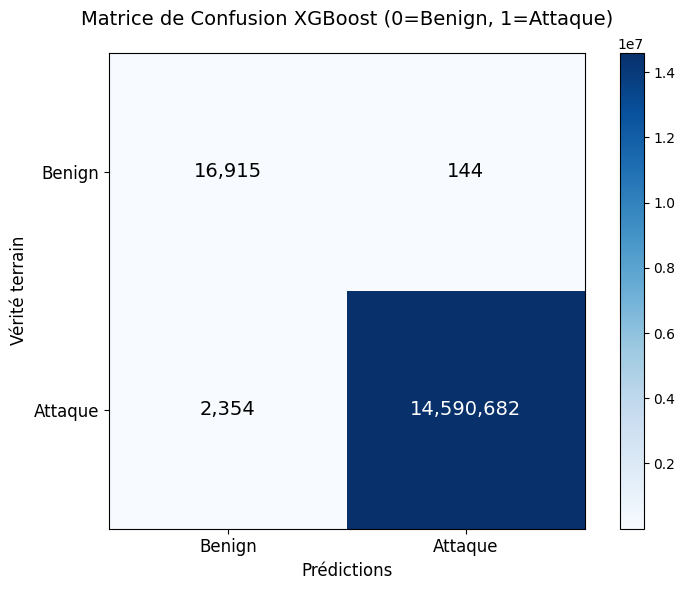

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion XGBoost (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_XGB.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")


 - Taux de Faux Positifs (FPR) : 0.0084
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0002



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")

Temps de prédiction : 1.33 secondes
Temps d'entrainement : 66.27 secondes


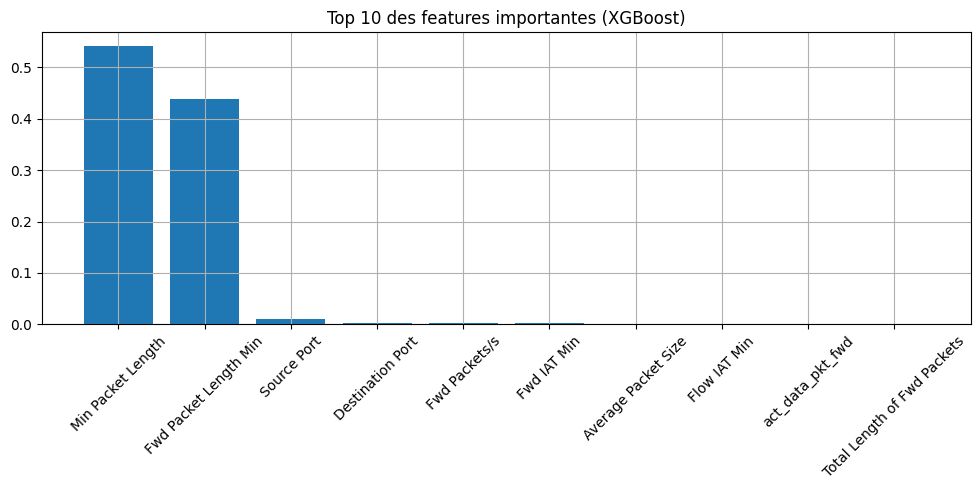

In [ ]:
# 10. Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # top 10
features = X_test.columns[indices]

plt.figure(figsize=(10, 5))
plt.title("Top 10 des features importantes (XGBoost)")
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), features, rotation=45)
plt.tight_layout()
plt.grid(True)
plt.savefig("feature_importance_XGB.png")
plt.show()

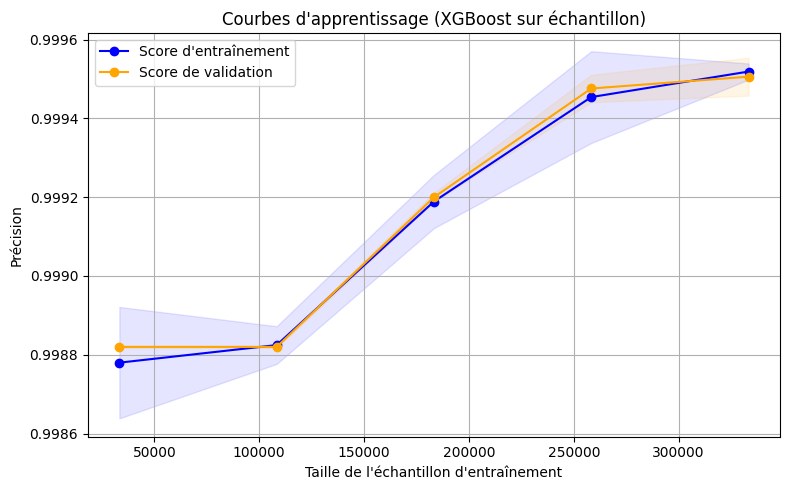

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

# Génération des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (XGBoost sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_XGB.png")
plt.show()

In [18]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 MB 3.4 MB/s eta 0:00:00


In [19]:
import joblib
modelxg = joblib.load('modelv1_xgboost_new.pkl')
print(type(modelxg))

<class 'xgboost.sklearn.XGBClassifier'>


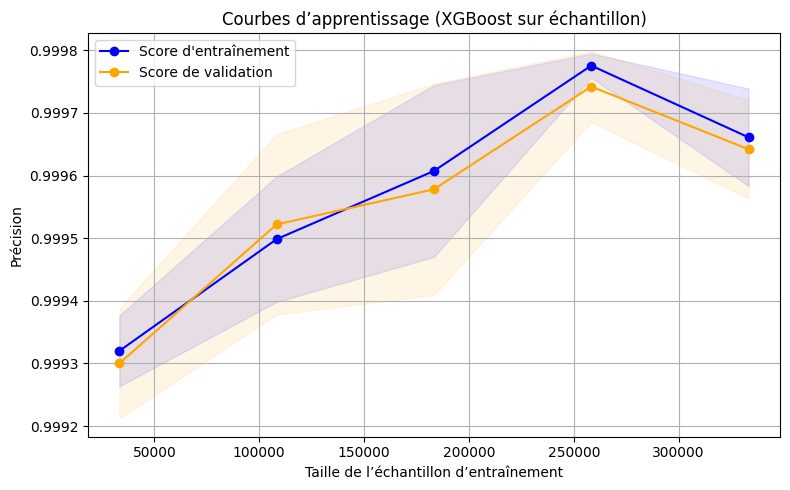

In [20]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_resampled, y_train_resampled, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelxg, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (XGBoost sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_xg_v2.png")
plt.show()


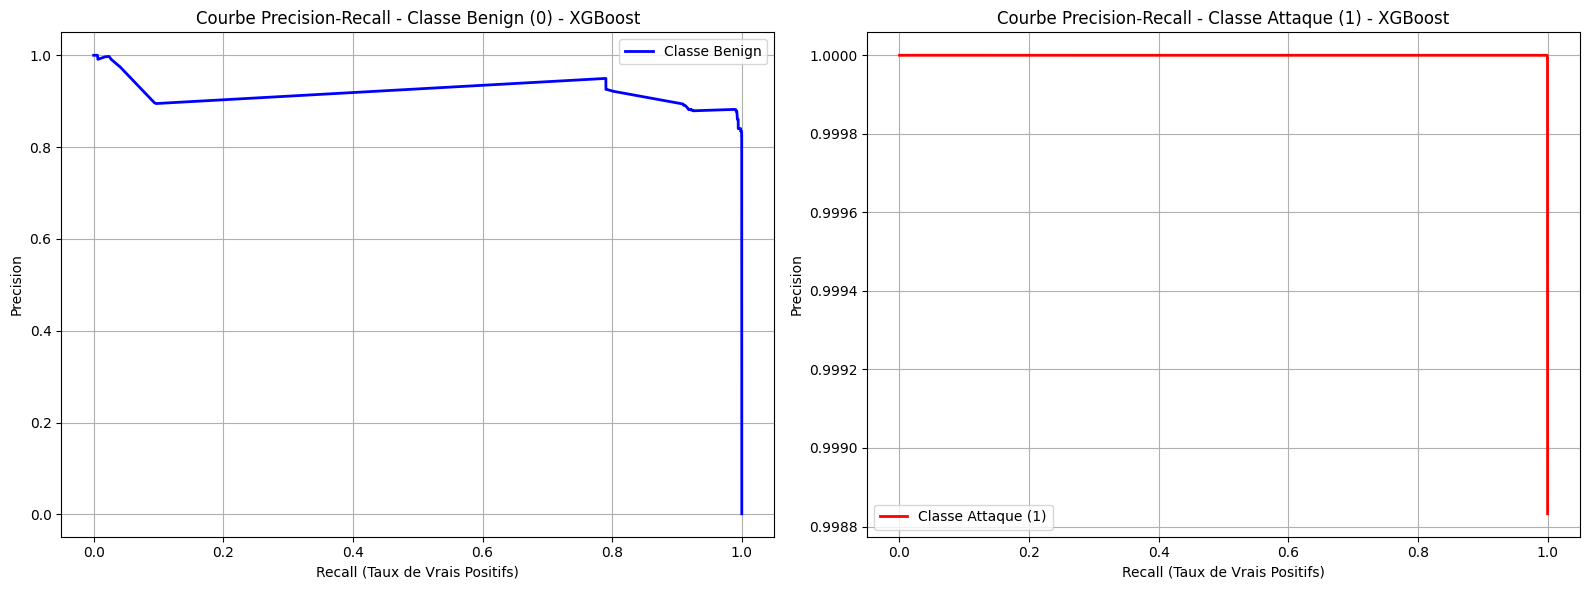

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign (version libre)
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0) - XGBoost')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque (version libre)
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1) - XGBoost')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# Ajustement automatique
plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1-XGB.png")
plt.show()

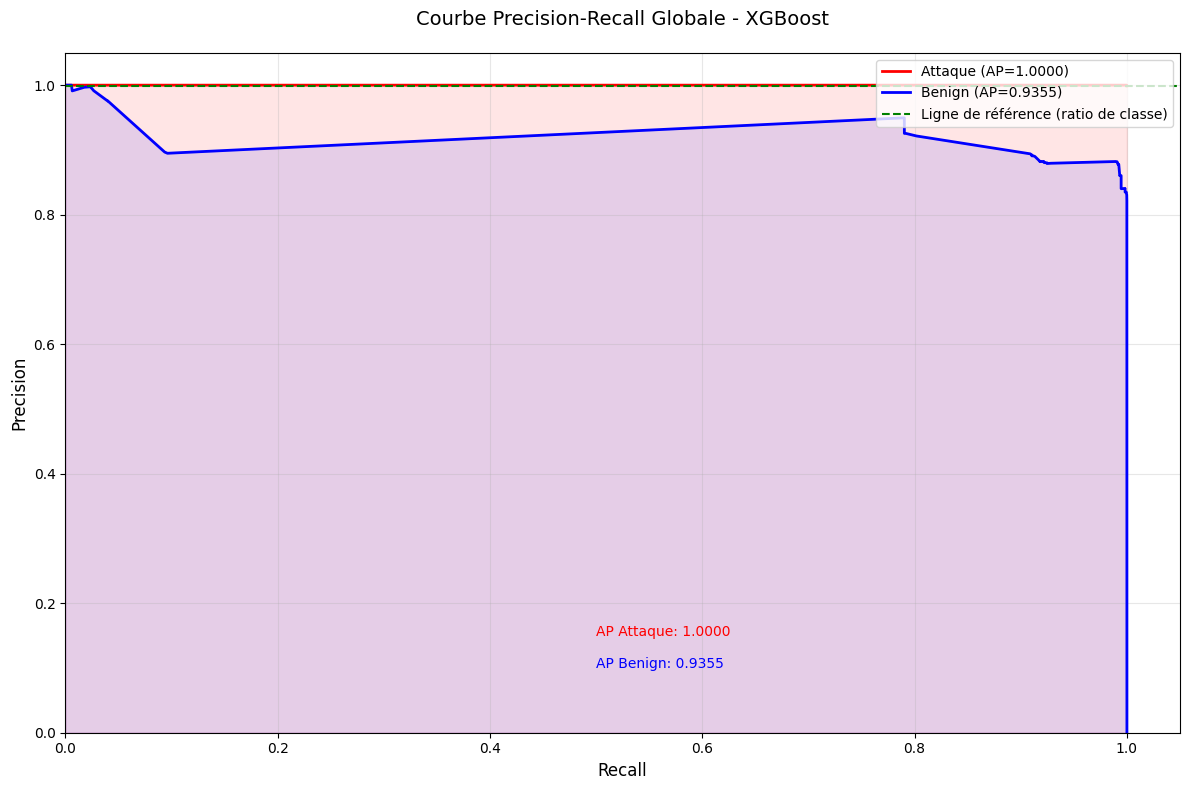

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# 1. Calcul pour les deux classes
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)

# 2. Calcul des Average Precision (AP)
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

# 3. Tracé global
plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

# Ligne de référence
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

# Mise en forme avancée
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale - XGBoost', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Annotations
plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

# Ajout des aires sous courbe
plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global-XGB.png")
plt.show()

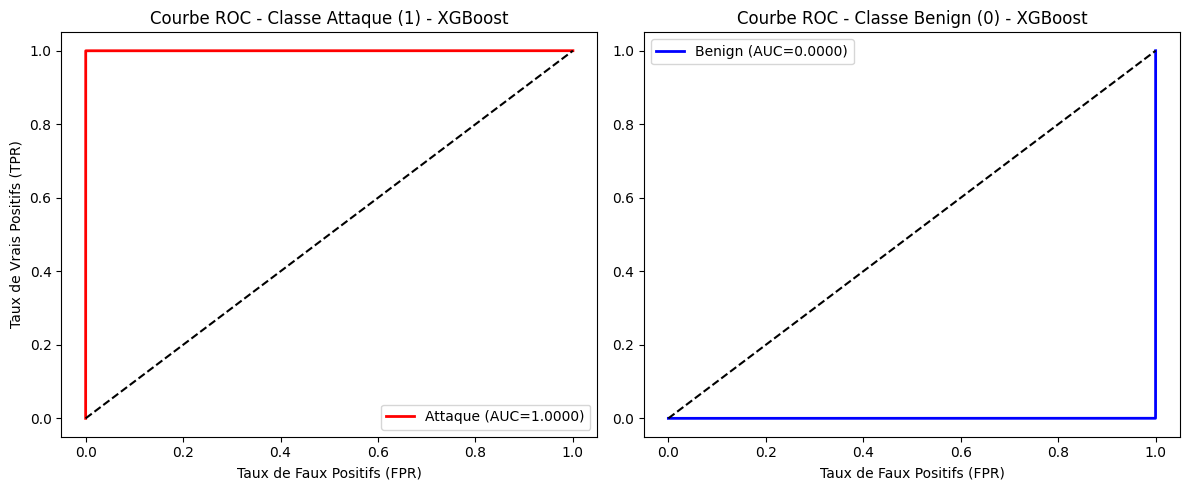

In [ ]:
# 1. Courbe ROC - Classe Attaque (pos_label=1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)  # Pas de pos_label ici

# 2. Courbe ROC - Classe Benign (pos_label=0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)  # Inversion des probabilités

# Tracé
plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1) - XGBoost')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0) - XGBoost')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1-XGB.png")
plt.show()

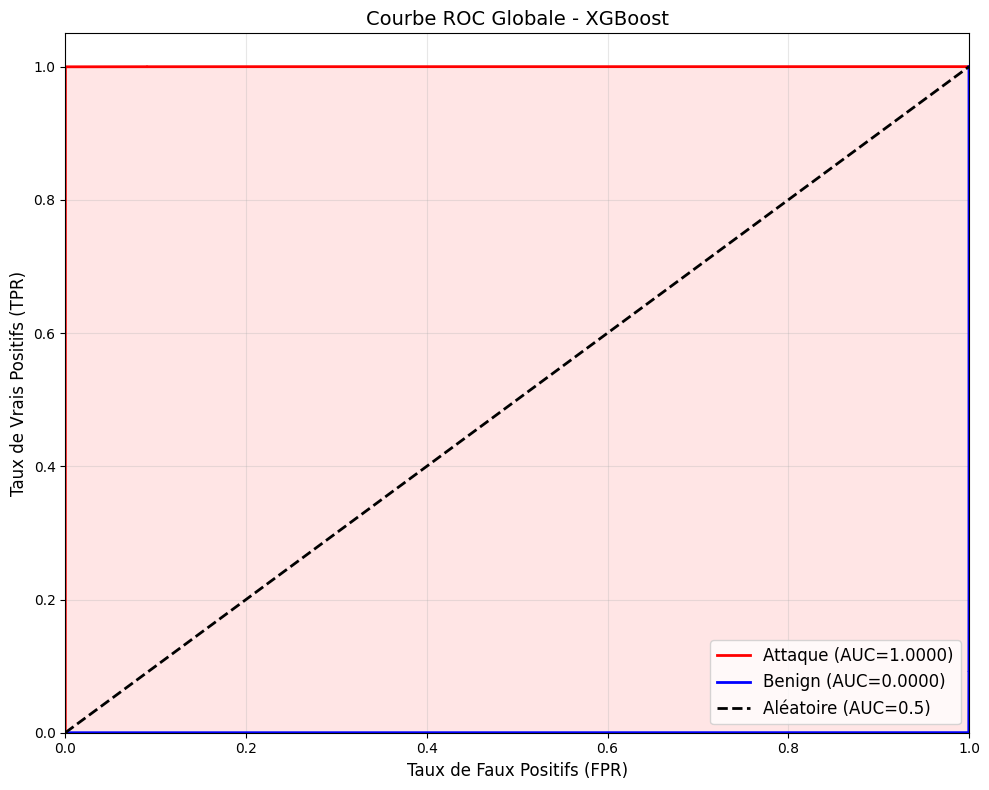

In [ ]:
# 1. Calcul pour la classe Attaque (1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

# 2. Calcul pour la classe Benign (0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

# 3. Tracé global
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

# Mise en forme
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - XGBoost', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Ajout des zones critiques
plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale-XGB.png")
plt.show()

In [ ]:
# Calcul des scores AUC-ROC
auc_attack = roc_auc_score(y_test, y_pred_prob)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)
auc_global = (auc_attack + auc_benign) / 2  # Moyenne macro

# Affichage formaté
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE XGBOOST ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE XGBOOST ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~~ PERFORMANCE DU MODÈLE XGBOOST ~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.999952
• AUC-ROC Classe Benign (0)  : 0.000048

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Calcul des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

# Affichage formaté
print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE XGBOOST      ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_xgboost.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE XGBOOST      ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE XGBOOST      ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.8778   ║ 1.0000   ║ 0.9389 ║
║ Recall       ║ 0.9916   ║ 0.9998   ║ 0.9957 ║
║ F1-Score     ║ 0.9312   ║ 0.9999   ║ 0.9656 ║
║ Accuracy     ║          ║          ║ 0.9998 ║
╚══════════════╩══════════╩══════════╩════════╝


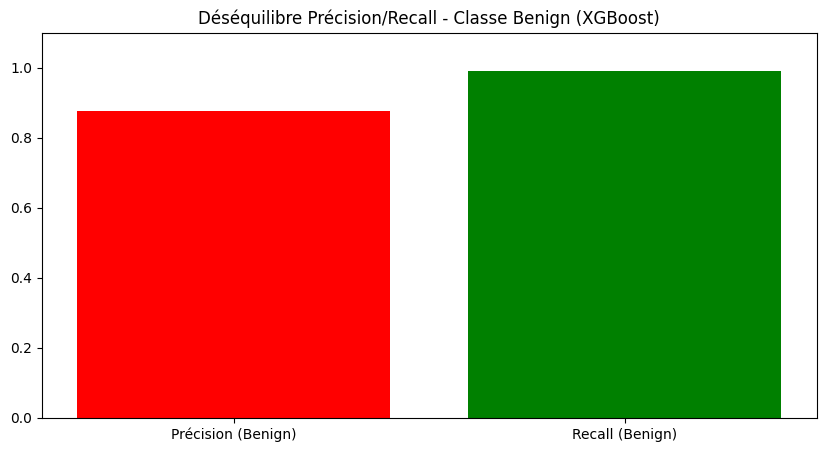

In [ ]:
# Récupération automatique des valeurs depuis le dictionnaire `metrics`
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (XGBoost)')

# Sauvegarde et affichage
plt.savefig("Desequilibre-Precision-Recall-Benign-XGB.png")
plt.show()

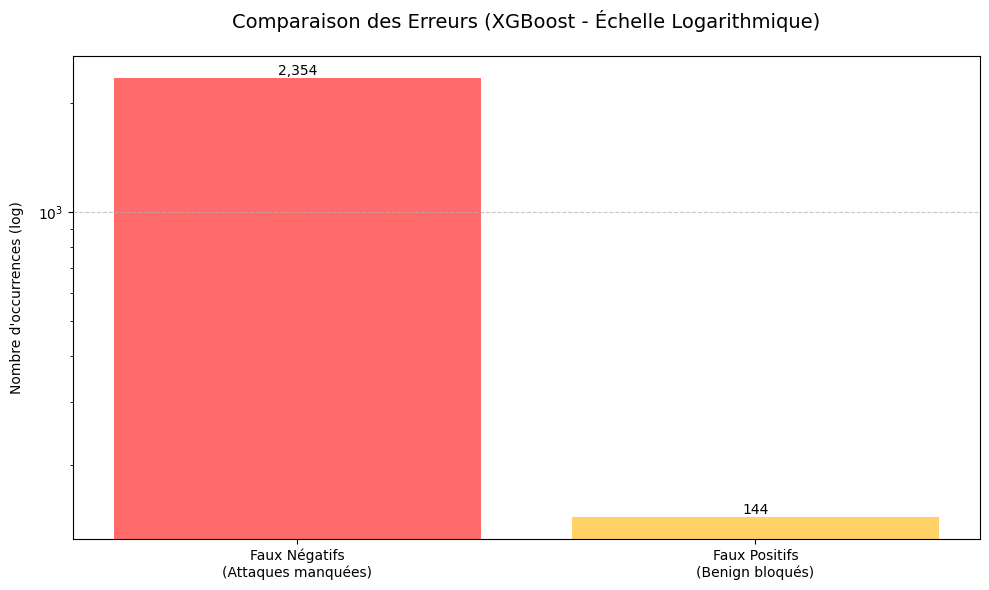

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction automatique depuis la matrice de confusion
TN, FP, FN, TP = cm.ravel()
values = [FN, FP]  # Faux Négatifs, Faux Positifs

# Données du graphique
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Barres avec échelle log pour voir les FP
bars = ax.bar(labels, values, color=colors, log=True)

# Ajout des valeurs exactes sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# Mise en forme
ax.set_title('Comparaison des Erreurs (XGBoost - Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel('Nombre d\'occurrences (log)', labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP-XGB.png")
plt.show()

# Naive bayes

In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
from sklearn.naive_bayes import GaussianNB

In [ ]:
model = GaussianNB()


In [ ]:
import time

start_train = time.time()
model.fit(X_train_resampled, y_train_resampled)
end_train = time.time()


In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_naive_bayes_new.pkl')

import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v1_NB_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv1_naive_bayes_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle sauvegardé et compressé avec succès dans : v1_NB_model_new.zip


In [ ]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
y_proba_val = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

In [ ]:
start_pred = time.time()
# --- 5. Évaluation finale sur le test set ---
y_pred_prob = model.predict_proba(X_test_normalized)[:, 1]
y_pred = (y_pred_prob > optimal_threshold).astype(int)
end_pred = time.time()


In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_NB.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE NAIVE BAYES           \n")
    f.write("═"*60 + "\n\n")


In [ ]:
# Évaluer
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_NB.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")

Classification Report :
               precision    recall  f1-score   support

           0       0.06      0.05      0.06     17059
           1       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.53      0.52      0.53  14610095
weighted avg       1.00      1.00      1.00  14610095

Confusion Matrix :
 [[     853    16206]
 [   12682 14580354]]


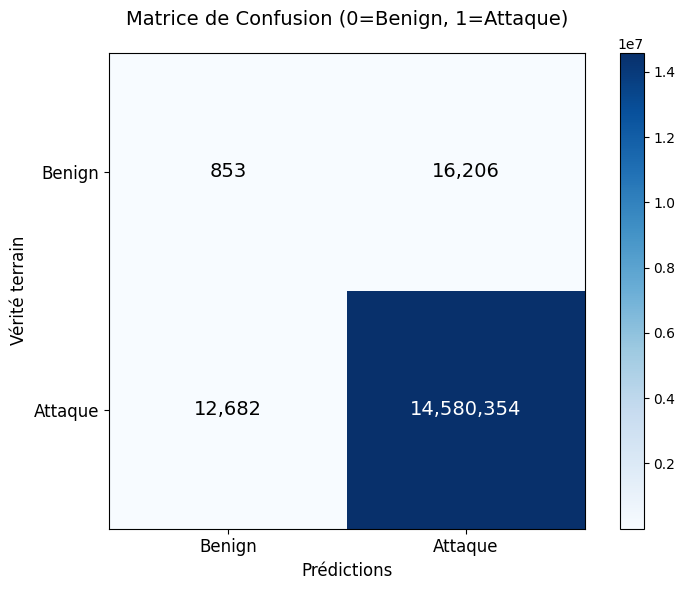

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_NB.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_NB.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")


 - Taux de Faux Positifs (FPR) : 0.9500
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0009



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_NB.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")


Temps de prédiction : 8.52 secondes
Temps d'entrainement : 26.80 secondes


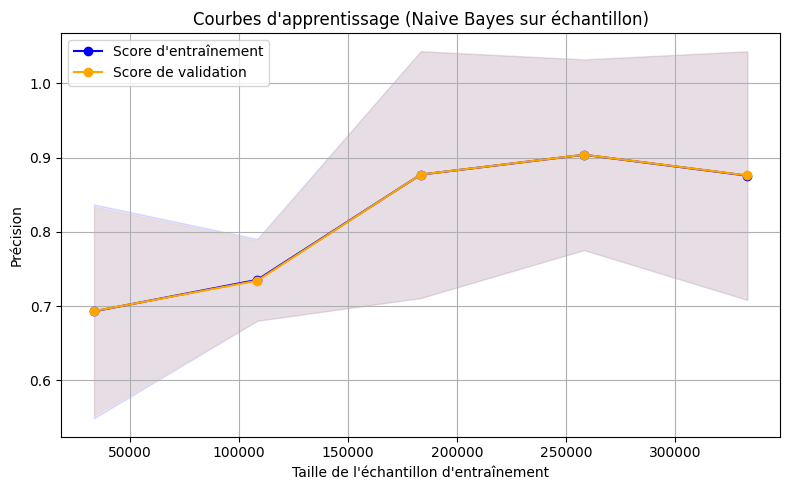

In [ ]:
# Courbes d'apprentissage
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_test, y_test, n_samples=500000, random_state=42)

# Génération des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (Naive Bayes sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_NB.png")
plt.show()

In [21]:
import joblib
modelnb = joblib.load('modelv1_naive_bayes_new.pkl')
print(type(modelnb))

<class 'sklearn.naive_bayes.GaussianNB'>


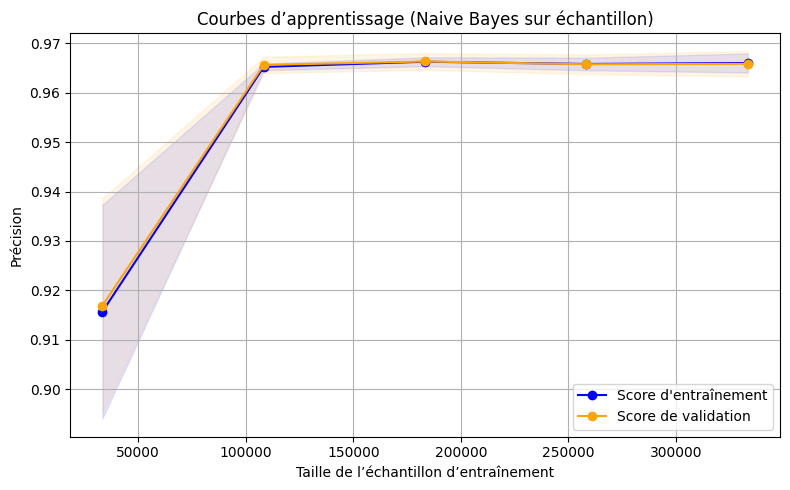

In [22]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_resampled, y_train_resampled, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelnb, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (Naive Bayes sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_nb_v2.png")
plt.show()


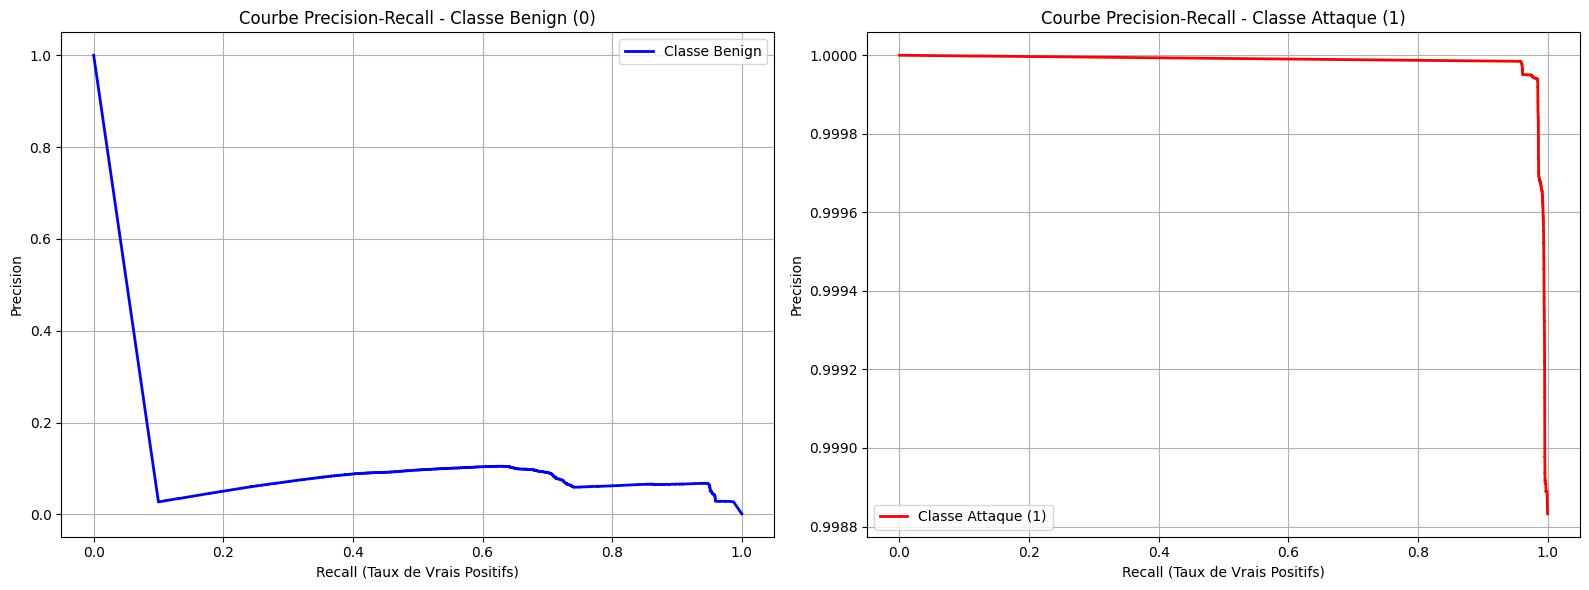

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign (version libre)
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Benign (0)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque (version libre)
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - Classe Attaque (1)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# Ajustement automatique
plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1_NB.png")
plt.show()

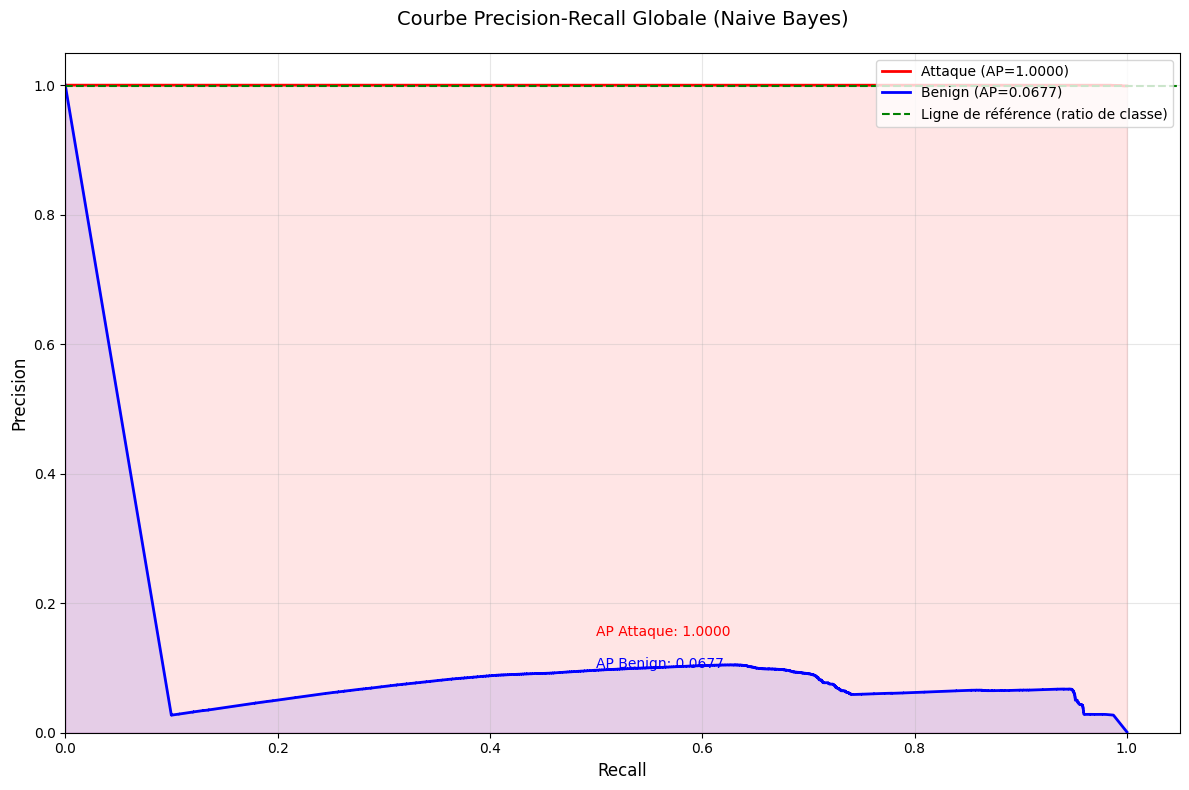

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# 1. Calcul pour les deux classes
precision_attack, recall_attack, _ = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test, 1 - y_pred_prob, pos_label=0)

# 2. Calcul des Average Precision (AP)
ap_attack = average_precision_score(y_test, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test, 1 - y_pred_prob, pos_label=0)

# 3. Tracé global
plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

# Ligne de référence
plt.axhline(y=len(y_test[y_test==1])/len(y_test), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

# Mise en forme avancée
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale (Naive Bayes)', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Annotations
plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

# Ajout des aires sous courbe
plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global_NB.png")
plt.show()

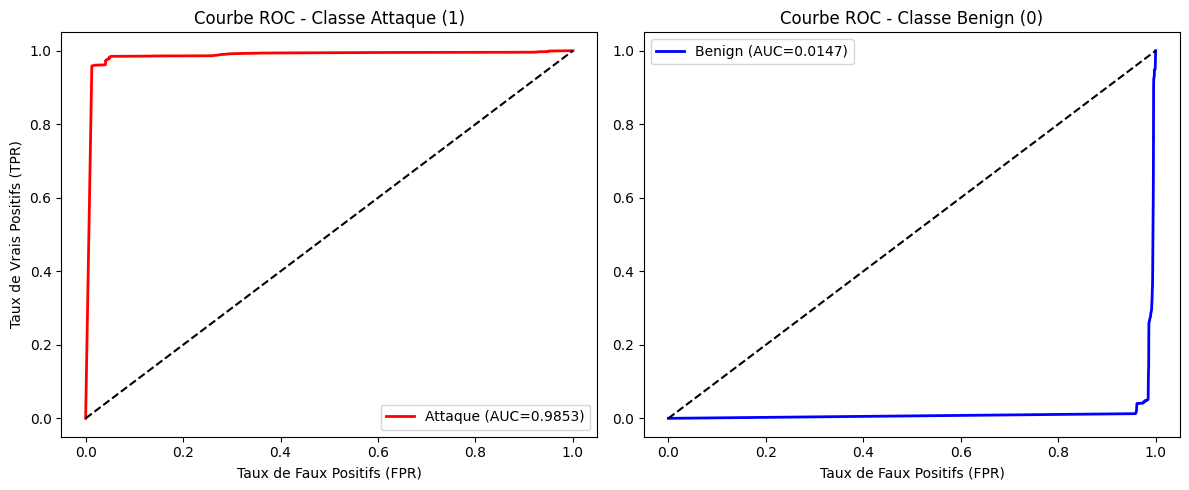

In [ ]:
# 1. Courbe ROC - Classe Attaque (pos_label=1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)  # Pas de pos_label ici

# 2. Courbe ROC - Classe Benign (pos_label=0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)  # Inversion des probabilités

# Tracé
plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1_NB.png")
plt.show()


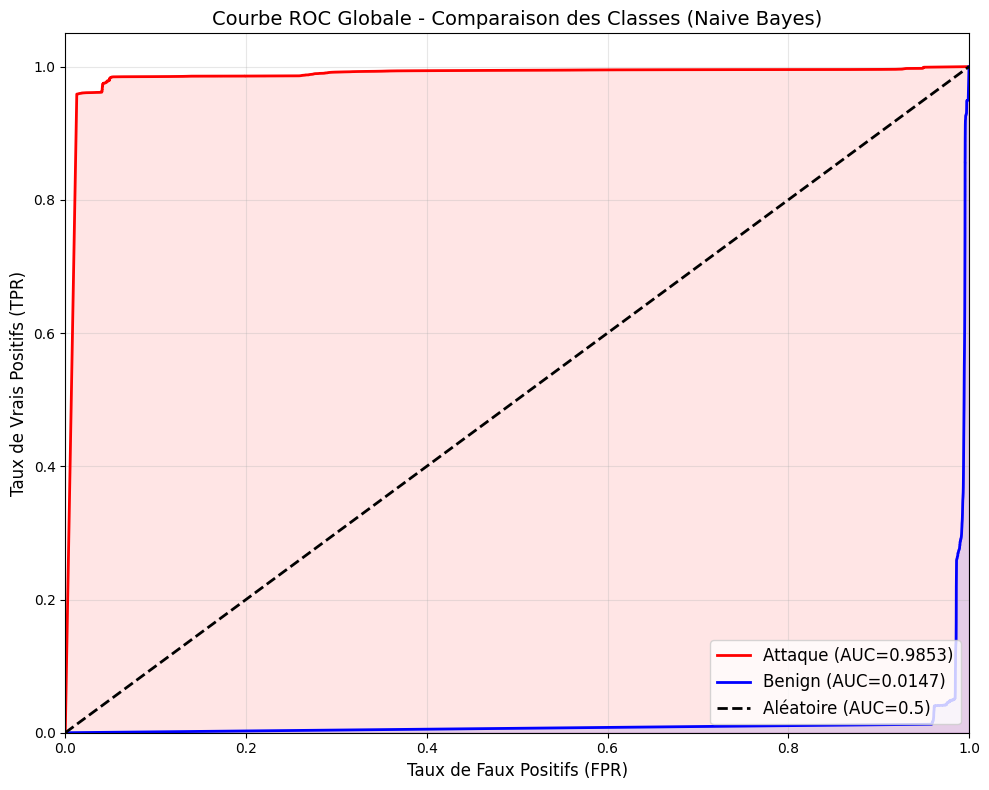

In [ ]:
# 1. Calcul pour la classe Attaque (1)
fpr_attack, tpr_attack, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test, y_pred_prob)

# 2. Calcul pour la classe Benign (0)
fpr_benign, tpr_benign, _ = roc_curve(y_test, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)

# 3. Tracé global
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

# Mise en forme
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale - Comparaison des Classes (Naive Bayes)', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Ajout des zones critiques
plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale_NB.png")
plt.show()

In [ ]:
# Calcul des scores AUC-ROC
auc_attack = roc_auc_score(y_test, y_pred_prob)
auc_benign = roc_auc_score(y_test, 1 - y_pred_prob)
auc_global = (auc_attack + auc_benign) / 2  # Moyenne macro

# Affichage formaté
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE NAIVE BAYES ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_NB.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE NAIVE BAYES ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~ PERFORMANCE DU MODÈLE NAIVE BAYES ~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.985317
• AUC-ROC Classe Benign (0)  : 0.014702

• AUC-ROC Global (macro)     : 0.500009

══════════════════════════════════════════════════


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Calcul des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test, y_pred, pos_label=0),
        'Attaque': precision_score(y_test, y_pred, pos_label=1),
        'Global': precision_score(y_test, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test, y_pred, pos_label=0),
        'Attaque': recall_score(y_test, y_pred, pos_label=1),
        'Global': recall_score(y_test, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test, y_pred, pos_label=0),
        'Attaque': f1_score(y_test, y_pred, pos_label=1),
        'Global': f1_score(y_test, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test, y_pred)
    }
}

# Affichage formaté
print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_NB.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE NAIVE BAYES  ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.0630   ║ 0.9989   ║ 0.5310 ║
║ Recall       ║ 0.0500   ║ 0.9991   ║ 0.5246 ║
║ F1-Score     ║ 0.0558   ║ 0.9990   ║ 0.5274 ║
║ Accuracy     ║          ║          ║ 0.9980 ║
╚══════════════╩══════════╩══════════╩════════╝


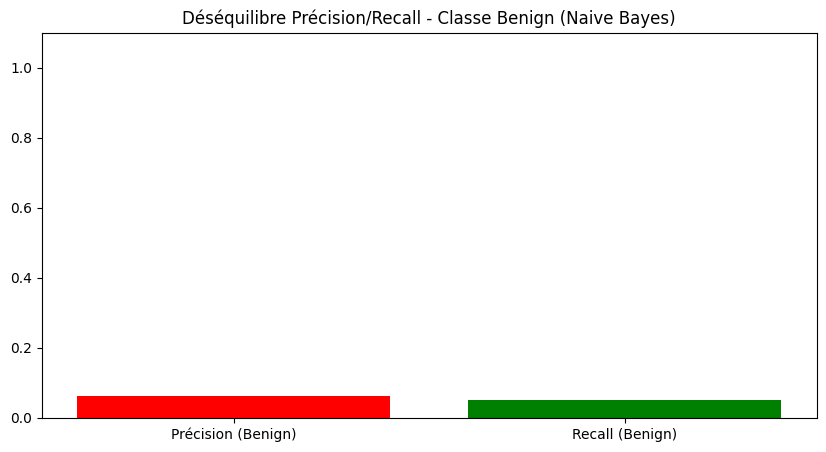

In [ ]:
# Récupération automatique des valeurs depuis le dictionnaire `metrics`
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall - Classe Benign (Naive Bayes)')

# Sauvegarde et affichage
plt.savefig("Desequilibre-Precision-Recall-Benign_NB.png")
plt.show()

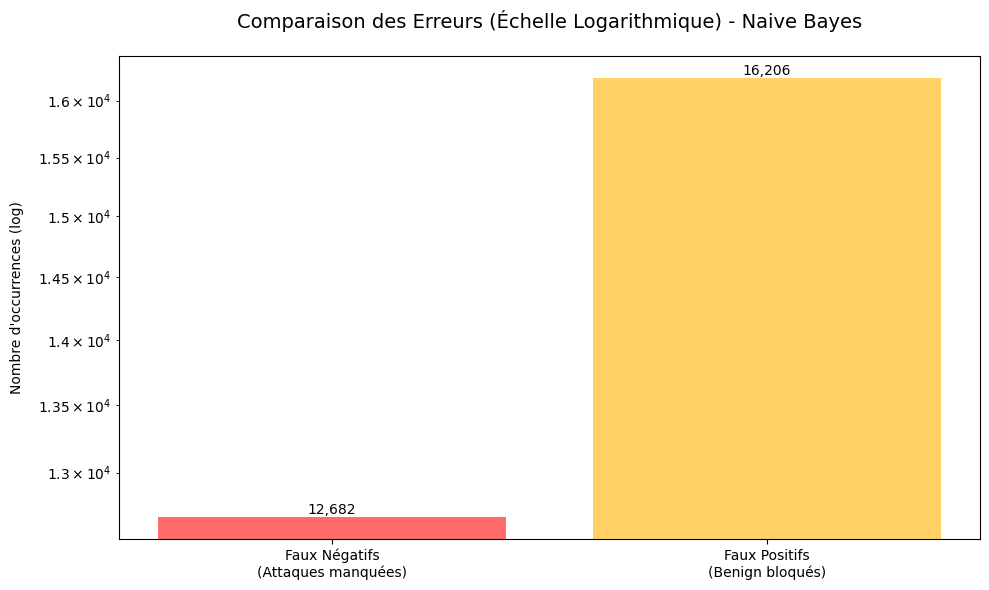

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction automatique depuis la matrice de confusion
TN, FP, FN, TP = cm.ravel()
values = [FN, FP]  # Faux Négatifs, Faux Positifs

# Données du graphique
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Barres avec échelle log pour voir les FP
bars = ax.bar(labels, values, color=colors, log=True)

# Ajout des valeurs exactes sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# Mise en forme
ax.set_title('Comparaison des Erreurs (Échelle Logarithmique) - Naive Bayes', pad=20, fontsize=14)
ax.set_ylabel("Nombre d'occurrences (log)", labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP_NB.png")
plt.show()

# KNN

In [23]:
# Sélection de 1 000 000 échantillons pour l'entraînement
X_train_res_small, _, y_train_res_small, _ = train_test_split(
    X_train_resampled, y_train_resampled,
    train_size=1_000_000,
    stratify=y_train_resampled,
    random_state=42
)

In [ ]:
# Sélection de 500 000 échantillons pour le test
X_test_normalized_small, _, y_test_small, _ = train_test_split(
    X_test_normalized, y_test,
    train_size=500_000,
    stratify=y_test,
    random_state=42
)

In [ ]:
# Sélection de 250 000 échantillons pour la validation
X_val_small, _, y_val_small, _ = train_test_split(
    X_val, y_val,
    train_size=250_000,
    stratify=y_val,
    random_state=42
)

In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    algorithm='auto',
    leaf_size=30,
    p=2,  # Distance euclidienne
    metric='minkowski',
    n_jobs=-1
)

In [ ]:
import time

start_train = time.time()
model.fit(X_train_res_small, y_train_res_small)
end_train = time.time()

In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_knn_new.pkl')

import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v1_KNN_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv1_knn_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")


Modèle sauvegardé et compressé avec succès dans : v1_KNN_model_new.zip


In [ ]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
y_proba_val = model.predict_proba(X_val_small)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val_small, y_proba_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]


In [ ]:
start_pred = time.time()
# --- 5. Évaluation finale sur le test set ---
y_pred_prob = model.predict_proba(X_test_normalized_small)[:, 1]
y_pred = (y_pred_prob > optimal_threshold).astype(int)
end_pred = time.time()

In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_knn.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE KNN           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test_small, y_pred)
matrix = confusion_matrix(y_test_small, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")

Classification Report :
               precision    recall  f1-score   support

           0       0.83      1.00      0.91       584
           1       1.00      1.00      1.00    499416

    accuracy                           1.00    500000
   macro avg       0.92      1.00      0.95    500000
weighted avg       1.00      1.00      1.00    500000

Confusion Matrix :
 [[   583      1]
 [   119 499297]]


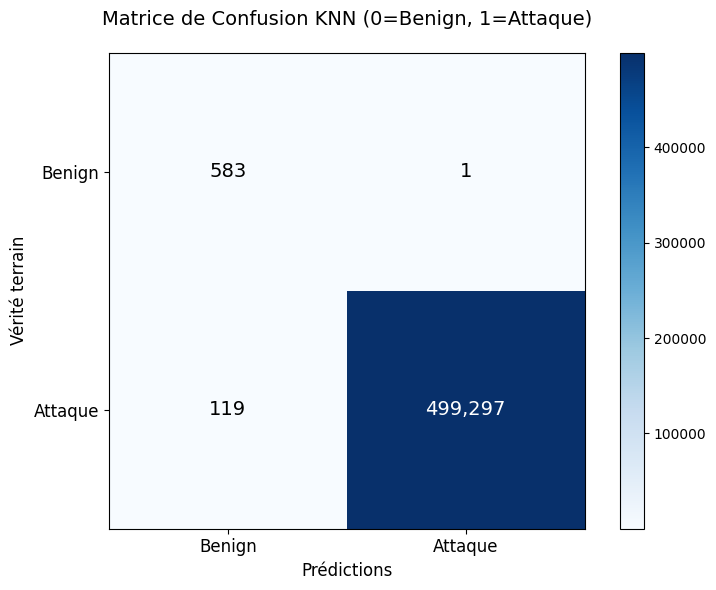

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_small, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion KNN (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_KNN.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

 - Taux de Faux Positifs (FPR) : 0.0017
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0002



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")

Temps de prédiction : 669.25 secondes
Temps d'entrainement : 0.04 secondes


In [ ]:
# Note: KNN n'a pas de feature importance native comme Random Forest
# On peut utiliser des méthodes alternatives comme permutation importance si nécessaire

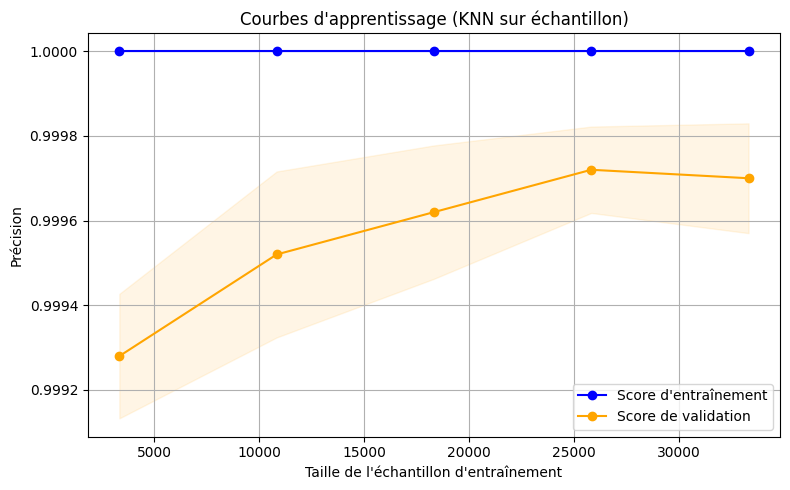

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples (réduit pour KNN)
X_sample, y_sample = resample(X_test_normalized_small, y_test_small, n_samples=50000, random_state=42)  # Réduit pour performance

# Génération des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (KNN sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_knn.png")
plt.show()

In [24]:
import joblib
modelknn = joblib.load('modelv1_knn_new.pkl')
print(type(modelknn))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


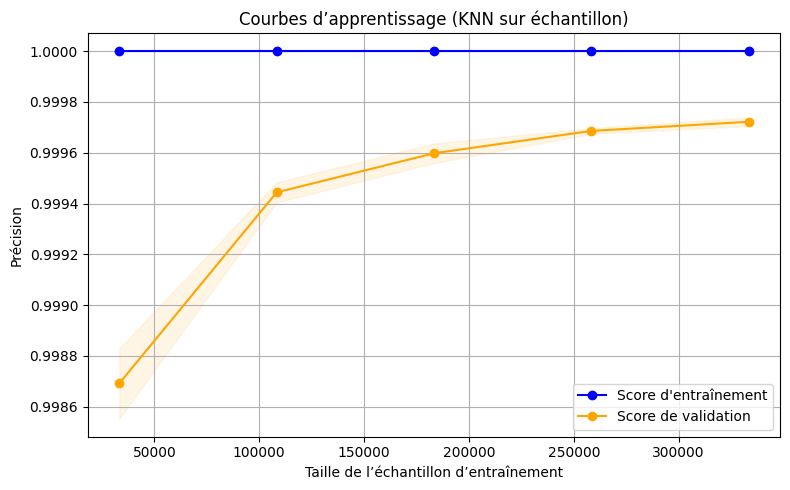

In [26]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_res_small, y_train_res_small, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelknn, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (KNN sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_knn_v2.png")
plt.show()


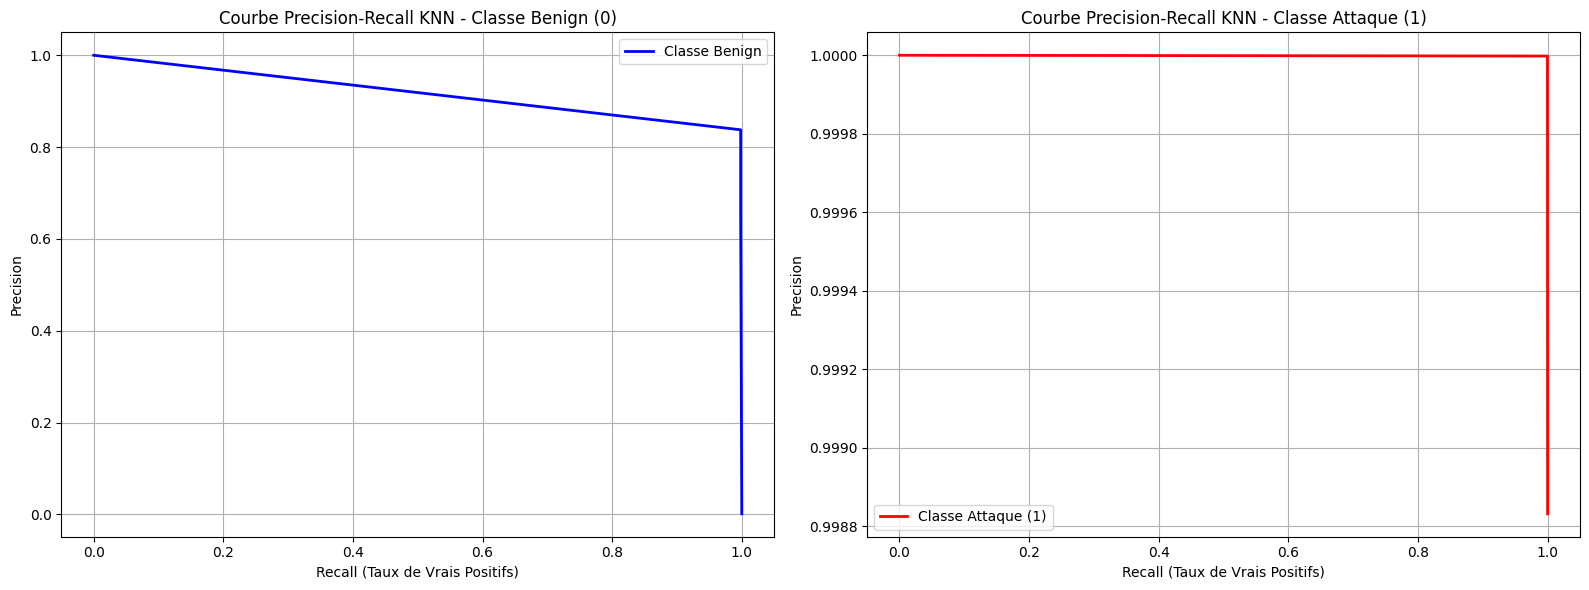

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign (version libre)
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test_small, 1 - y_pred_prob, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall KNN - Classe Benign (0)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque (version libre)
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test_small, y_pred_prob, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall KNN - Classe Attaque (1)')
plt.legend()
plt.grid()
# Suppression des limites forcées
plt.autoscale(enable=True, axis='both', tight=False)

# Ajustement automatique
plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1-knn.png")
plt.show()


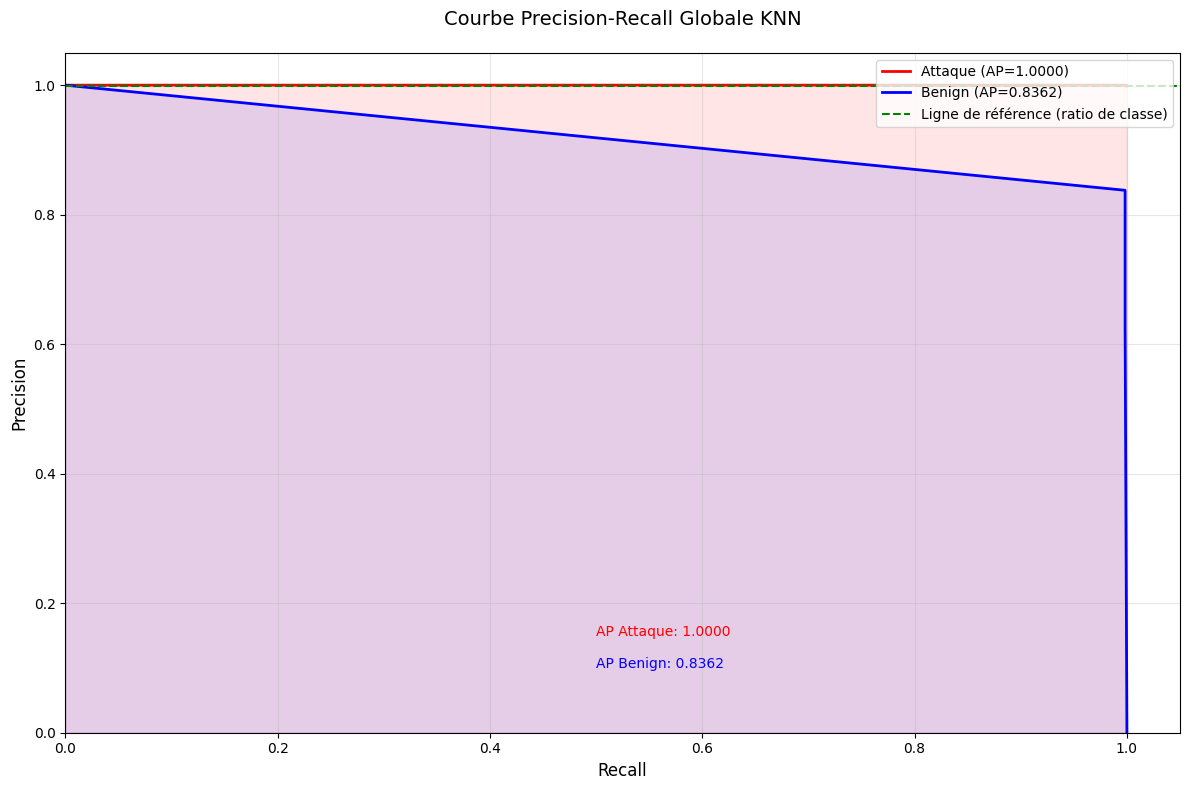

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# 1. Calcul pour les deux classes
precision_attack, recall_attack, _ = precision_recall_curve(y_test_small, y_pred_prob, pos_label=1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test_small, 1 - y_pred_prob, pos_label=0)

# 2. Calcul des Average Precision (AP)
ap_attack = average_precision_score(y_test_small, y_pred_prob, pos_label=1)
ap_benign = average_precision_score(y_test_small, 1 - y_pred_prob, pos_label=0)

# 3. Tracé global
plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

# Ligne de référence
plt.axhline(y=len(y_test_small[y_test_small==1])/len(y_test_small), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

# Mise en forme avancée
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale KNN', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Annotations
plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

# Ajout des aires sous courbe
plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global-knn.png")
plt.show()

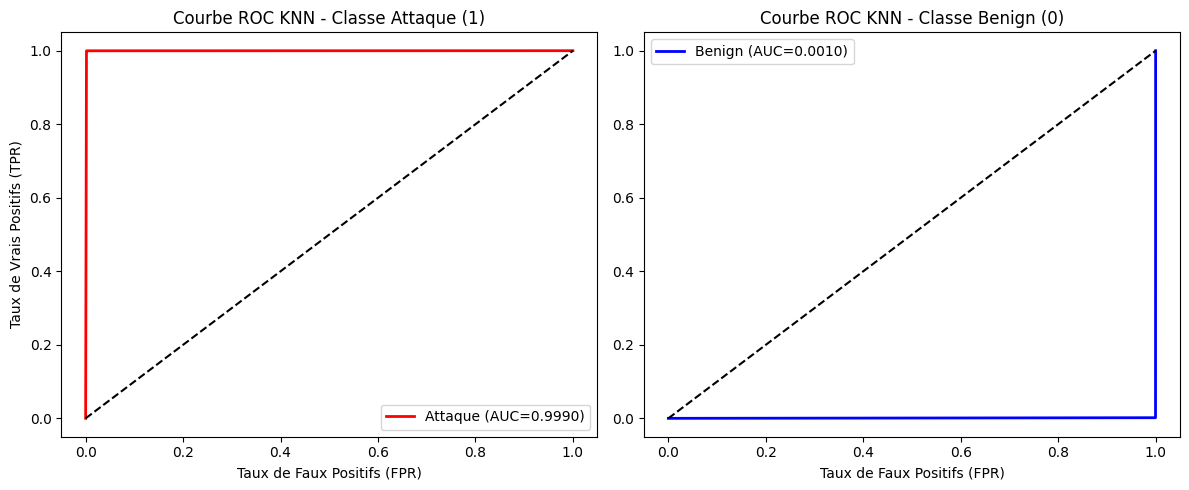

In [ ]:
# 1. Courbe ROC - Classe Attaque (pos_label=1)
fpr_attack, tpr_attack, _ = roc_curve(y_test_small, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test_small, y_pred_prob)  # Pas de pos_label ici

# 2. Courbe ROC - Classe Benign (pos_label=0)
fpr_benign, tpr_benign, _ = roc_curve(y_test_small, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test_small, 1 - y_pred_prob)  # Inversion des probabilités

# Tracé
plt.figure(figsize=(12, 5))

# Subplot gauche - Attaque
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC KNN - Classe Attaque (1)')
plt.legend()

# Subplot droit - Benign
plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC KNN - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1-knn.png")
plt.show()

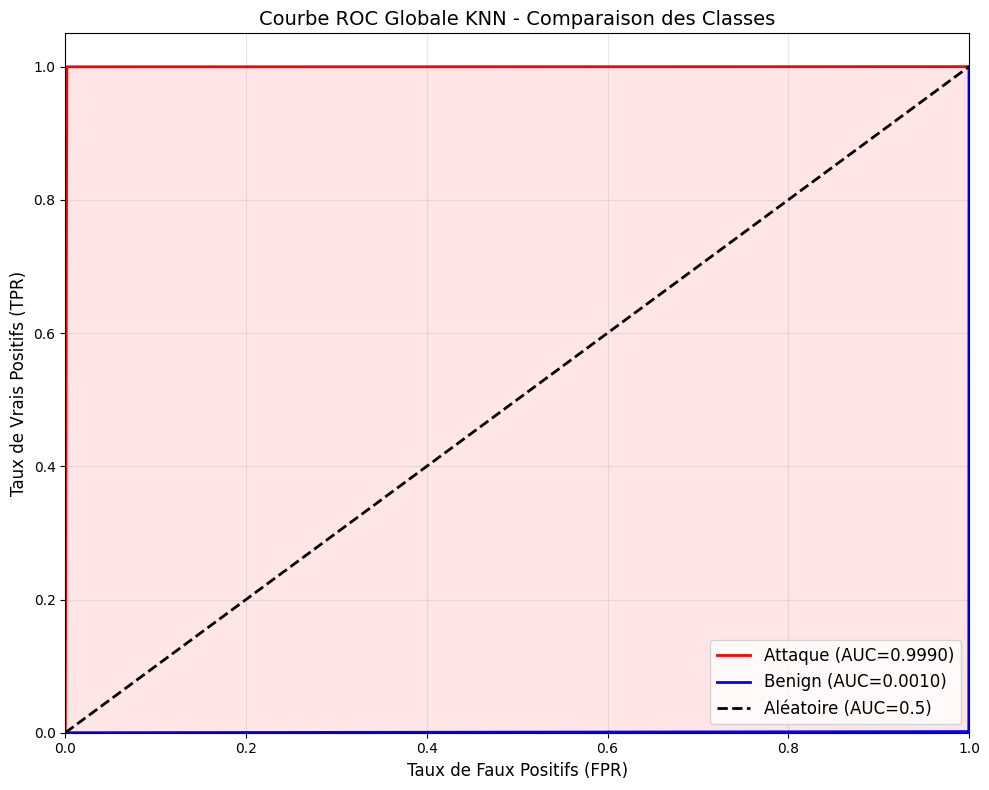

In [ ]:
# 1. Calcul pour la classe Attaque (1)
fpr_attack, tpr_attack, _ = roc_curve(y_test_small, y_pred_prob, pos_label=1)
auc_attack = roc_auc_score(y_test_small, y_pred_prob)

# 2. Calcul pour la classe Benign (0)
fpr_benign, tpr_benign, _ = roc_curve(y_test_small, y_pred_prob, pos_label=0)
auc_benign = roc_auc_score(y_test_small, 1 - y_pred_prob)

# 3. Tracé global
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

# Mise en forme
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale KNN - Comparaison des Classes', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Ajout des zones critiques
plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale-knn.png")
plt.show()

In [ ]:
# Calcul des scores AUC-ROC
auc_attack = roc_auc_score(y_test_small, y_pred_prob)
auc_benign = roc_auc_score(y_test_small, 1 - y_pred_prob)
auc_global = (auc_attack + auc_benign) / 2  # Moyenne macro

# Affichage formaté
print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE KNN ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE KNN ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~~~~ PERFORMANCE DU MODÈLE KNN ~~~~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.999030
• AUC-ROC Classe Benign (0)  : 0.000970

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Calcul des métriques
metrics = {
    'Précision': {
        'Benign': precision_score(y_test_small, y_pred, pos_label=0),
        'Attaque': precision_score(y_test_small, y_pred, pos_label=1),
        'Global': precision_score(y_test_small, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test_small, y_pred, pos_label=0),
        'Attaque': recall_score(y_test_small, y_pred, pos_label=1),
        'Global': recall_score(y_test_small, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test_small, y_pred, pos_label=0),
        'Attaque': f1_score(y_test_small, y_pred, pos_label=1),
        'Global': f1_score(y_test_small, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test_small, y_pred)
    }
}

# Affichage formaté
print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE KNN          ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_knn.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE KNN          ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE KNN          ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.8305   ║ 1.0000   ║ 0.9152 ║
║ Recall       ║ 0.9983   ║ 0.9998   ║ 0.9990 ║
║ F1-Score     ║ 0.9067   ║ 0.9999   ║ 0.9533 ║
║ Accuracy     ║          ║          ║ 0.9998 ║
╚══════════════╩══════════╩══════════╩════════╝


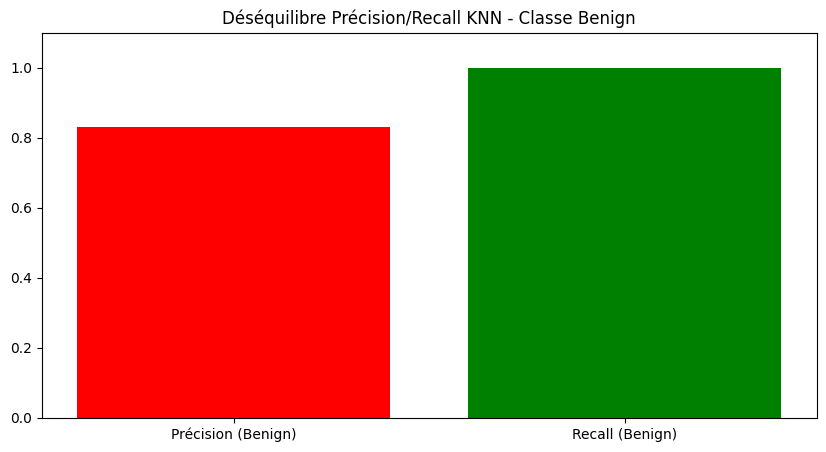

In [ ]:
# Récupération automatique des valeurs depuis le dictionnaire `metrics`
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

# Création du graphique
plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall KNN - Classe Benign')

# Sauvegarde et affichage
plt.savefig("Desequilibre-Precision-Recall-Benign-knn.png")
plt.show()

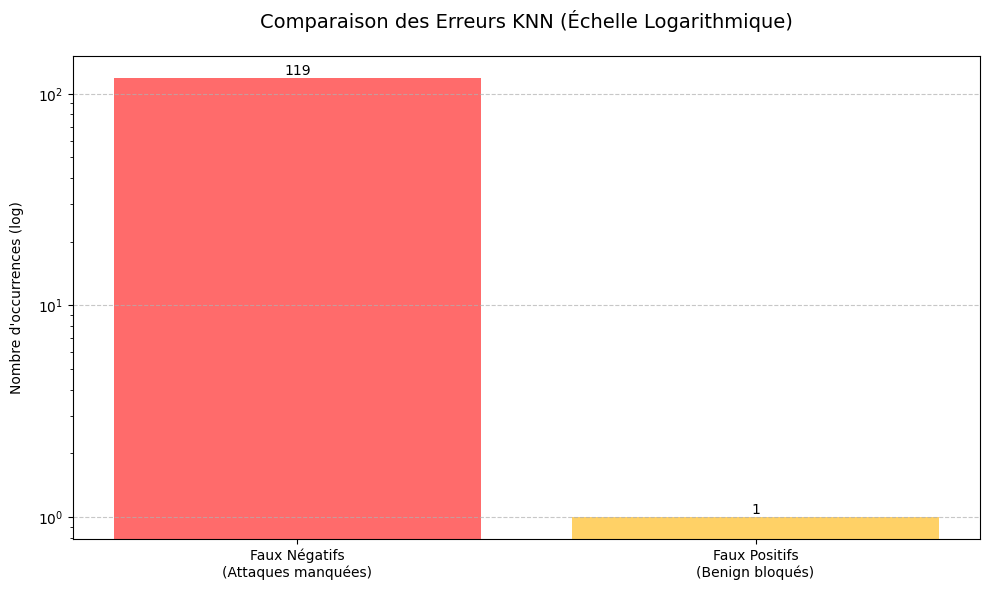

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction automatique depuis la matrice de confusion
TN, FP, FN, TP = cm.ravel()
values = [FN, FP]  # Faux Négatifs, Faux Positifs

# Données du graphique
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
colors = ['#ff6b6b', '#ffd166']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Barres avec échelle log pour voir les FP
bars = ax.bar(labels, values, color=colors, log=True)

# Ajout des valeurs exactes sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

# Mise en forme
ax.set_title('Comparaison des Erreurs KNN (Échelle Logarithmique)', pad=20, fontsize=14)
ax.set_ylabel('Nombre d\'occurrences (log)', labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP-knn.png")
plt.show()

# SVM LinearSVC

In [ ]:
# Sélection de 1 000 000 échantillons pour l'entraînement
#X_train_res_small, _, y_train_res_small, _ = train_test_split(
#    X_train_resampled, y_train_resampled,
#    train_size=1_000_000,
#    stratify=y_train_resampled,
#    random_state=42
#)
# Sélection de 500 000 échantillons pour le test
#X_test_normalized_small, _, y_test_small, _ = train_test_split(
#    X_test_normalized, y_test,
#    train_size=500_000,
#    stratify=y_test,
#    random_state=42
#)
# Sélection de 250 000 échantillons pour la validation
#X_val_small, _, y_val_small, _ = train_test_split(
#    X_val, y_val,
#    train_size=250_000,
#    stratify=y_val,
#    random_state=42
#)

In [ ]:
# --- 3. Entraînement sur données rééquilibrées ---
from sklearn.svm import LinearSVC
model = LinearSVC(
    C=1.0,
    class_weight='balanced',  # Pour gérer le déséquilibre de classe
    random_state=42,
    max_iter=1000,
    dual=False,  # Préférable quand n_samples > n_features
    verbose=1
)

In [ ]:
import time
start_train = time.time()
model.fit(X_train_res_small, y_train_res_small)
end_train = time.time()


[LibLinear]

In [ ]:
import joblib
# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(model, 'modelv1_linearsvc_new.pkl')

import zipfile
# 3. Créer un fichier ZIP et y ajouter le .pkl
zip_filename = 'v1_LinearSVC_model_new.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('modelv1_linearsvc_new.pkl')
print(f"Modèle sauvegardé et compressé avec succès dans : {zip_filename}")

Modèle sauvegardé et compressé avec succès dans : v1_LinearSVC_model_new.zip


In [ ]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
# Note: LinearSVC n'a pas predict_proba par défaut, on utilise decision_function
decision_scores_val = model.decision_function(X_val_small)
precision, recall, thresholds = precision_recall_curve(y_val_small, decision_scores_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]


In [ ]:
start_pred = time.time()
# --- 5. Évaluation finale sur le test set ---
decision_scores_test = model.decision_function(X_test_normalized_small)
y_pred = (decision_scores_test > optimal_threshold).astype(int)
end_pred = time.time()

In [ ]:
# Création initiale du fichier avec un en-tête
with open("resultats_analyse_linearsvc.txt", "w", encoding="utf-8") as f:
    f.write("═"*60 + "\n")
    f.write("           RAPPORT D'ÉVALUATION DU MODÈLE LinearSVC           \n")
    f.write("═"*60 + "\n\n")

In [ ]:
# Évaluer
report = classification_report(y_test_small, y_pred)
matrix = confusion_matrix(y_test_small, y_pred)

# Affichage
print("Classification Report :\n", report)
print("Confusion Matrix :\n", matrix)

# Sauvegarde dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("=== RAPPORT DE CLASSIFICATION ===\n")
    f.write(report + "\n")
    f.write("=== MATRICE DE CONFUSION ===\n")
    f.write(np.array2string(matrix, separator=' ') + "\n\n")


Classification Report :
               precision    recall  f1-score   support

           0       0.96      0.09      0.17       584
           1       1.00      1.00      1.00    499416

    accuracy                           1.00    500000
   macro avg       0.98      0.55      0.58    500000
weighted avg       1.00      1.00      1.00    500000

Confusion Matrix :
 [[    53    531]
 [     2 499414]]


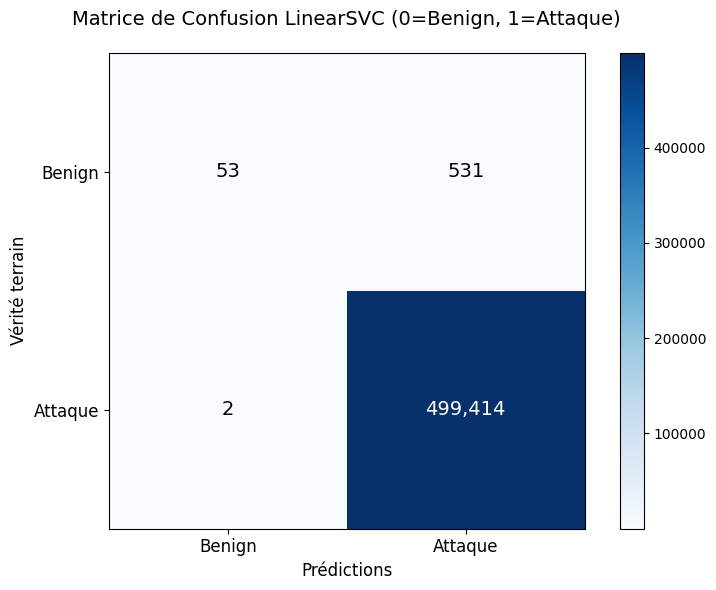

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test_small, y_pred)

# Création d'une visualisation claire
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion LinearSVC (0=Benign, 1=Attaque)', fontsize=14, pad=20)
plt.colorbar()

# Configuration des axes
class_names = ['Benign', 'Attaque']
plt.xticks([0, 1], class_names, fontsize=12)
plt.yticks([0, 1], class_names, fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)

# Ajout des valeurs annotées
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",  # Format avec séparateurs de milliers
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

# Affichage et sauvegarde
plt.tight_layout()
plt.savefig('matrice_confusion_LinearSVC.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Calcul du FPR à partir de la matrice de confusion
TN, FP, FN, TP = cm.ravel()  # Récupère les valeurs de la matrice de confusion

FPR = FP / (FP + TN)  # Taux de faux positifs (FPR)
print(f""" - Taux de Faux Positifs (FPR) : {FPR:.4f}""")

FNR = FN / (FN + TP)
print(f""" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}
""")

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write(f" - Taux de Faux Positifs (FPR) : {FPR:.4f}\n")
    f.write(f" - Taux de Faux Négatifs (Attaques manquées) FNR: {FNR:.4f}\n\n")

 - Taux de Faux Positifs (FPR) : 0.9092
 - Taux de Faux Négatifs (Attaques manquées) FNR: 0.0000



In [ ]:
# 8. Temps de prédiction et d'entrainement
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print(f"Temps d'entrainement : {end_train - start_train:.2f} secondes")
temps_prediction = end_pred - start_pred
temps_train = end_train - start_train

# Enregistrement dans le fichier texte sans écrasement
with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write(f"Temps de prédiction : {temps_prediction:.2f} secondes\n\n")
    f.write(f"Temps d'entrainement  : {temps_train:.2f} secondes\n\n")

Temps de prédiction : 0.15 secondes
Temps d'entrainement : 22.14 secondes


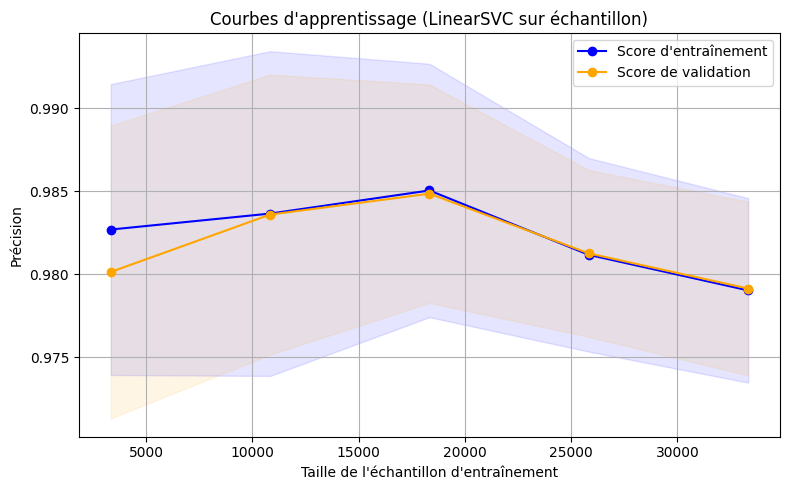

In [ ]:
# Courbes d'apprentissage (adapté pour LinearSVC)
from sklearn.model_selection import learning_curve
from sklearn.utils import resample

# Échantillonnage stratifié pour un sous-ensemble réduit
X_sample, y_sample = resample(X_test_normalized_small, y_test_small, n_samples=50000, random_state=42)

# Génération des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d'apprentissage (LinearSVC sur échantillon)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_linearsvc.png")
plt.show()

In [27]:
import joblib
modelsvm = joblib.load('modelv1_linearsvc_new.pkl')
print(type(modelsvm))

<class 'sklearn.svm._classes.LinearSVC'>


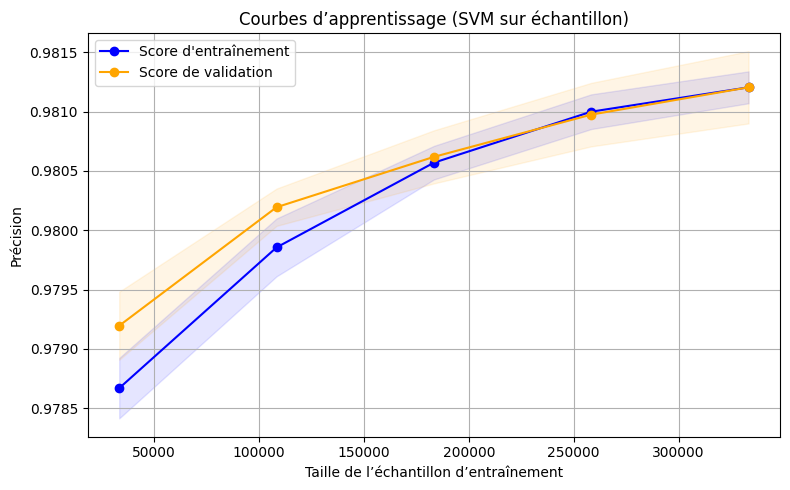

In [28]:

from sklearn.model_selection import learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np

# Échantillonnage stratifié pour un sous-ensemble de 500 000 exemples
X_sample, y_sample = resample(X_train_res_small, y_train_res_small, n_samples=500000, random_state=42)

# Génération des courbes d’apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modelsvm, X_sample, y_sample, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label="Score d'entraînement", color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label="Score de validation", color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.title("Courbes d’apprentissage (SVM sur échantillon)")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.savefig("learning_curve_train_svm_v2.png")
plt.show()


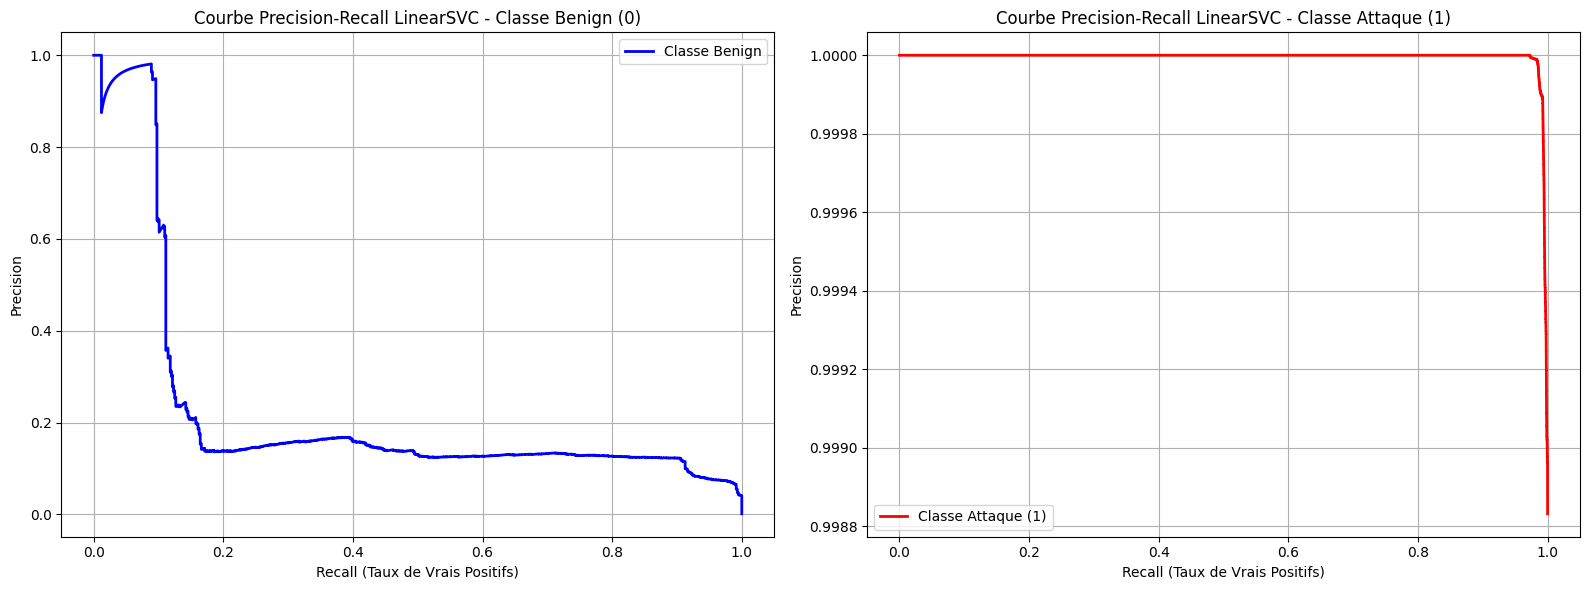

In [ ]:
# Configuration globale
plt.figure(figsize=(16, 6))

# =============================================
# 1. Subplot GAUCHE - Classe Benign
# =============================================
plt.subplot(1, 2, 1)
precision_benign, recall_benign, _ = precision_recall_curve(y_test_small, -decision_scores_test, pos_label=0)
plt.plot(recall_benign, precision_benign, color='blue', lw=2, label='Classe Benign')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall LinearSVC - Classe Benign (0)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

# =============================================
# 2. Subplot DROITE - Classe Attaque
# =============================================
plt.subplot(1, 2, 2)
precision_attack, recall_attack, _ = precision_recall_curve(y_test_small, decision_scores_test, pos_label=1)
plt.plot(recall_attack, precision_attack, color='red', lw=2, label='Classe Attaque (1)')
plt.xlabel('Recall (Taux de Vrais Positifs)')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall LinearSVC - Classe Attaque (1)')
plt.legend()
plt.grid()
plt.autoscale(enable=True, axis='both', tight=False)

plt.tight_layout()
plt.savefig("courbes-precision-recall-0-1-linearsvc.png")
plt.show()

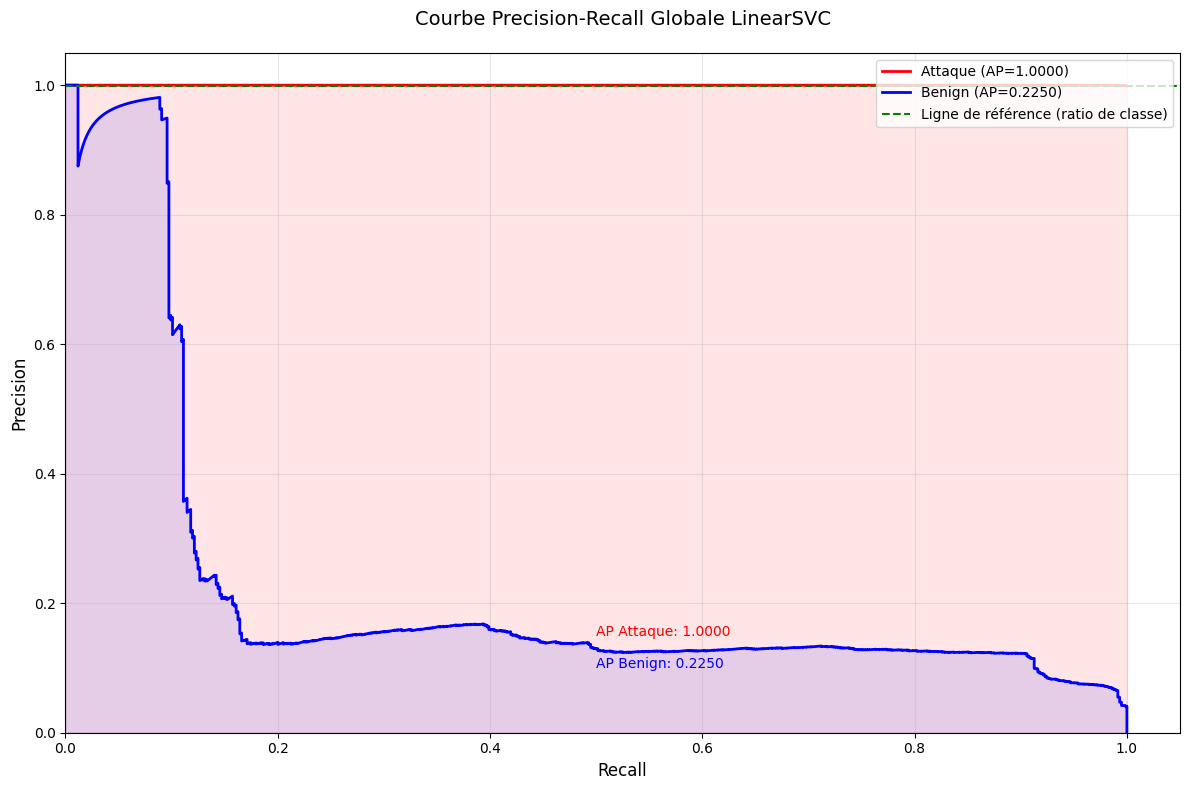

In [ ]:
# Courbe Precision-Recall globale
from sklearn.metrics import average_precision_score

ap_attack = average_precision_score(y_test_small, decision_scores_test, pos_label=1)
ap_benign = average_precision_score(y_test_small, -decision_scores_test, pos_label=0)

plt.figure(figsize=(12, 8))
plt.plot(recall_attack, precision_attack, color='red', lw=2,
         label=f'Attaque (AP={ap_attack:.4f})', linestyle='-')
plt.plot(recall_benign, precision_benign, color='blue', lw=2,
         label=f'Benign (AP={ap_benign:.4f})', linestyle='-')

plt.axhline(y=len(y_test_small[y_test_small==1])/len(y_test_small), color='green', linestyle='--',
            label='Ligne de référence (ratio de classe)')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbe Precision-Recall Globale LinearSVC', fontsize=14, pad=20)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.text(0.5, 0.15, f"AP Attaque: {ap_attack:.4f}", color='red', fontsize=10)
plt.text(0.5, 0.10, f"AP Benign: {ap_benign:.4f}", color='blue', fontsize=10)

plt.fill_between(recall_attack, precision_attack, color='red', alpha=0.1)
plt.fill_between(recall_benign, precision_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-precision-recall-global-linearsvc.png")
plt.show()


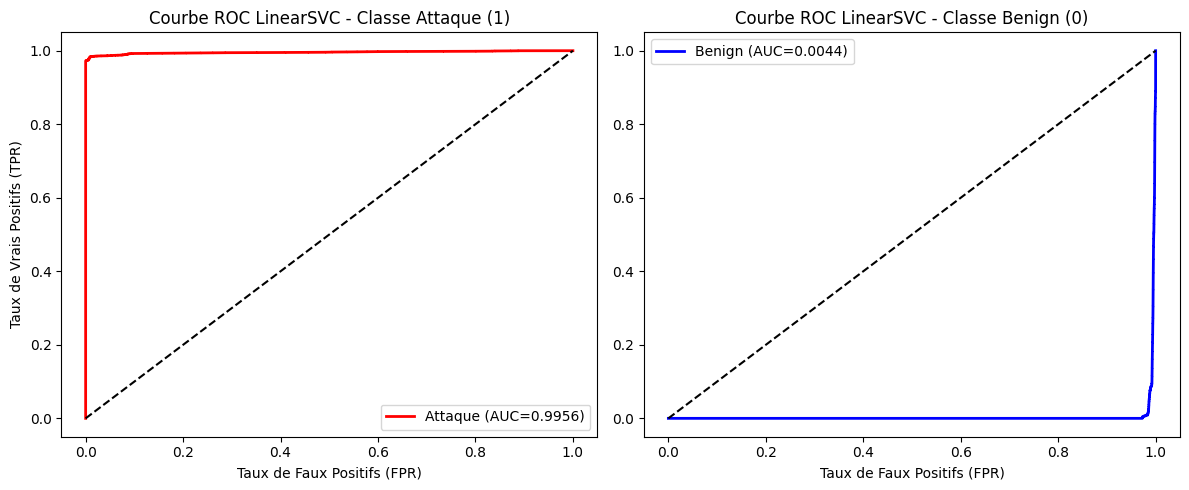

In [ ]:
# Courbes ROC
from sklearn.metrics import roc_curve, roc_auc_score

fpr_attack, tpr_attack, _ = roc_curve(y_test_small, decision_scores_test, pos_label=1)
auc_attack = roc_auc_score(y_test_small, decision_scores_test)

fpr_benign, tpr_benign, _ = roc_curve(y_test_small, decision_scores_test, pos_label=0)
auc_benign = roc_auc_score(y_test_small, -decision_scores_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_attack, tpr_attack, color='red', lw=2, label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC LinearSVC - Classe Attaque (1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2, label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.title('Courbe ROC LinearSVC - Classe Benign (0)')
plt.legend()

plt.tight_layout()
plt.savefig("courbes-ROC-0-1-linearsvc.png")
plt.show()

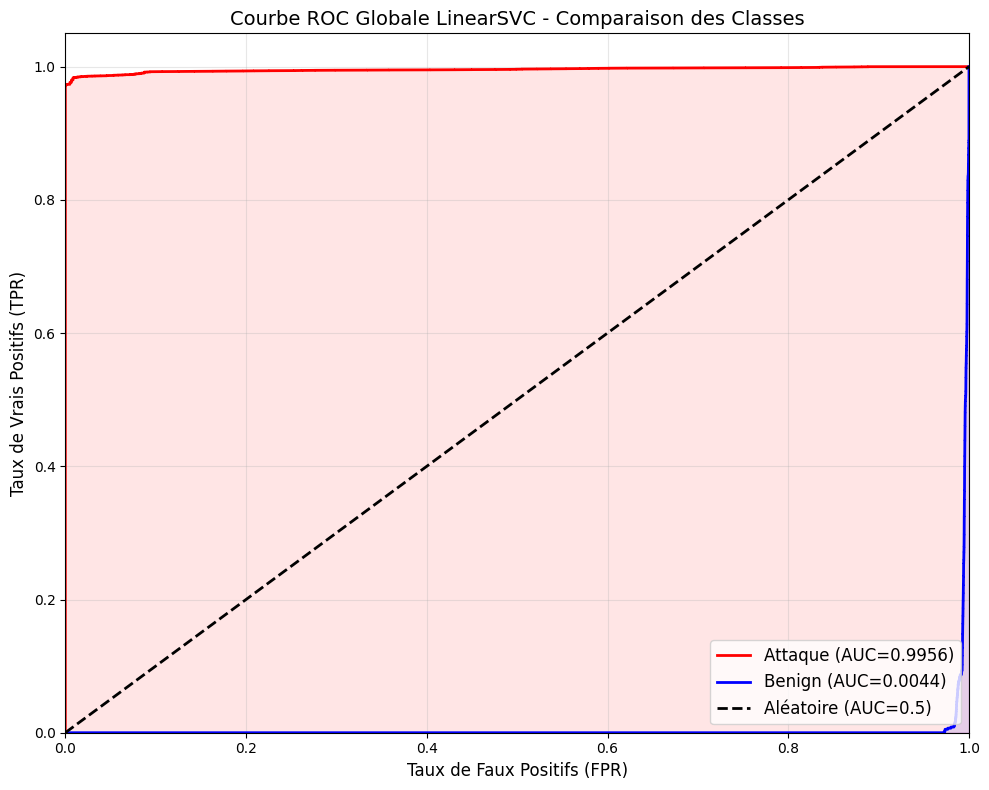

In [ ]:
# Courbe ROC globale
plt.figure(figsize=(10, 8))
plt.plot(fpr_attack, tpr_attack, color='red', lw=2,
         label=f'Attaque (AUC={auc_attack:.4f})')
plt.plot(fpr_benign, tpr_benign, color='blue', lw=2,
         label=f'Benign (AUC={auc_benign:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC Globale LinearSVC - Comparaison des Classes', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.fill_between(fpr_attack, tpr_attack, color='red', alpha=0.1)
plt.fill_between(fpr_benign, tpr_benign, color='blue', alpha=0.1)

plt.tight_layout()
plt.savefig("courbes-ROC-globale-linearsvc.png")
plt.show()

In [ ]:
# Affichage des AUC-ROC
auc_global = (auc_attack + auc_benign) / 2

print("\n" + "═"*50)
print(" PERFORMANCE DU MODÈLE LinearSVC ".center(50, "~"))
print("═"*50)
print(f"\n\033[1m• AUC-ROC Classe Attaque (1)\033[0m : {auc_attack:.6f}")
print(f"\033[1m• AUC-ROC Classe Benign (0)\033[0m  : {auc_benign:.6f}")
print(f"\n\033[1m• AUC-ROC Global (macro)\033[0m     : {auc_global:.6f}")
print("\n" + "═"*50)

with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("\n" + "═"*50 + "\n")
    f.write(" PERFORMANCE DU MODÈLE LinearSVC ".center(50, "~") + "\n")
    f.write("═"*50 + "\n")
    f.write(f"\n• AUC-ROC Classe Attaque (1) : {auc_attack:.6f}\n")
    f.write(f"• AUC-ROC Classe Benign (0)  : {auc_benign:.6f}\n")
    f.write(f"\n• AUC-ROC Global (macro)     : {auc_global:.6f}\n")
    f.write("═"*50 + "\n\n")


══════════════════════════════════════════════════
~~~~~~~~ PERFORMANCE DU MODÈLE LinearSVC ~~~~~~~~~
══════════════════════════════════════════════════

• AUC-ROC Classe Attaque (1) : 0.995625
• AUC-ROC Classe Benign (0)  : 0.004375

• AUC-ROC Global (macro)     : 0.500000

══════════════════════════════════════════════════


In [ ]:
# Tableau récapitulatif des métriques
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    'Précision': {
        'Benign': precision_score(y_test_small, y_pred, pos_label=0),
        'Attaque': precision_score(y_test_small, y_pred, pos_label=1),
        'Global': precision_score(y_test_small, y_pred, average='macro')
    },
    'Recall': {
        'Benign': recall_score(y_test_small, y_pred, pos_label=0),
        'Attaque': recall_score(y_test_small, y_pred, pos_label=1),
        'Global': recall_score(y_test_small, y_pred, average='macro')
    },
    'F1-Score': {
        'Benign': f1_score(y_test_small, y_pred, pos_label=0),
        'Attaque': f1_score(y_test_small, y_pred, pos_label=1),
        'Global': f1_score(y_test_small, y_pred, average='macro')
    },
    'Accuracy': {
        'Global': accuracy_score(y_test_small, y_pred)
    }
}

print("╔═════════════════════════════════════════════╗")
print("║          PERFORMANCE DU MODÈLE LinearSVC    ║")
print("╠══════════════╦══════════╦══════════╦════════╣")
print("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║")
print("╠══════════════╬══════════╬══════════╬════════╣")

for metric_name, values in metrics.items():
    if metric_name == 'Accuracy':
        print(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║")
    else:
        print(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║")

print("╚══════════════╩══════════╩══════════╩════════╝")

with open("resultats_analyse_linearsvc.txt", "a", encoding="utf-8") as f:
    f.write("╔═════════════════════════════════════════════╗\n")
    f.write("║          PERFORMANCE DU MODÈLE LinearSVC    ║\n")
    f.write("╠══════════════╦══════════╦══════════╦════════╣\n")
    f.write("║   Métrique   ║  Benign  ║ Attaque  ║ Global ║\n")
    f.write("╠══════════════╬══════════╬══════════╬════════╣\n")

    for metric_name, values in metrics.items():
        if metric_name == 'Accuracy':
            f.write(f"║ {metric_name:12} ║ {' ':8} ║ {' ':8} ║ {values['Global']:.4f} ║\n")
        else:
            f.write(f"║ {metric_name:12} ║ {values['Benign']:.4f}   ║ {values['Attaque']:.4f}   ║ {values['Global']:.4f} ║\n")

    f.write("╚══════════════╩══════════╩══════════╩════════╝\n\n")

╔═════════════════════════════════════════════╗
║          PERFORMANCE DU MODÈLE LinearSVC    ║
╠══════════════╦══════════╦══════════╦════════╣
║   Métrique   ║  Benign  ║ Attaque  ║ Global ║
╠══════════════╬══════════╬══════════╬════════╣
║ Précision    ║ 0.9636   ║ 0.9989   ║ 0.9813 ║
║ Recall       ║ 0.0908   ║ 1.0000   ║ 0.5454 ║
║ F1-Score     ║ 0.1659   ║ 0.9995   ║ 0.5827 ║
║ Accuracy     ║          ║          ║ 0.9989 ║
╚══════════════╩══════════╩══════════╩════════╝


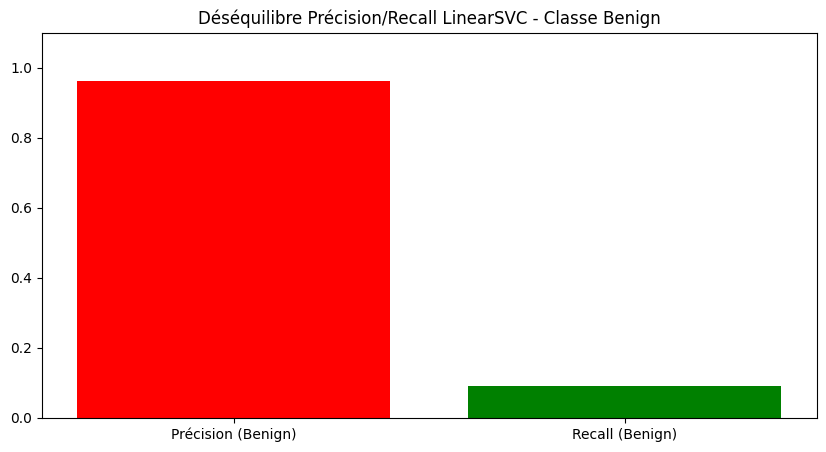

In [ ]:
# Graphique déséquilibre Précision/Recall
precision_benign = metrics['Précision']['Benign']
recall_benign = metrics['Recall']['Benign']

plt.figure(figsize=(10, 5))
plt.bar(['Précision (Benign)', 'Recall (Benign)'],
        [precision_benign, recall_benign],
        color=['red', 'green'])

plt.ylim(0, 1.1)
plt.title('Déséquilibre Précision/Recall LinearSVC - Classe Benign')
plt.savefig("Desequilibre-Precision-Recall-Benign-linearsvc.png")
plt.show()

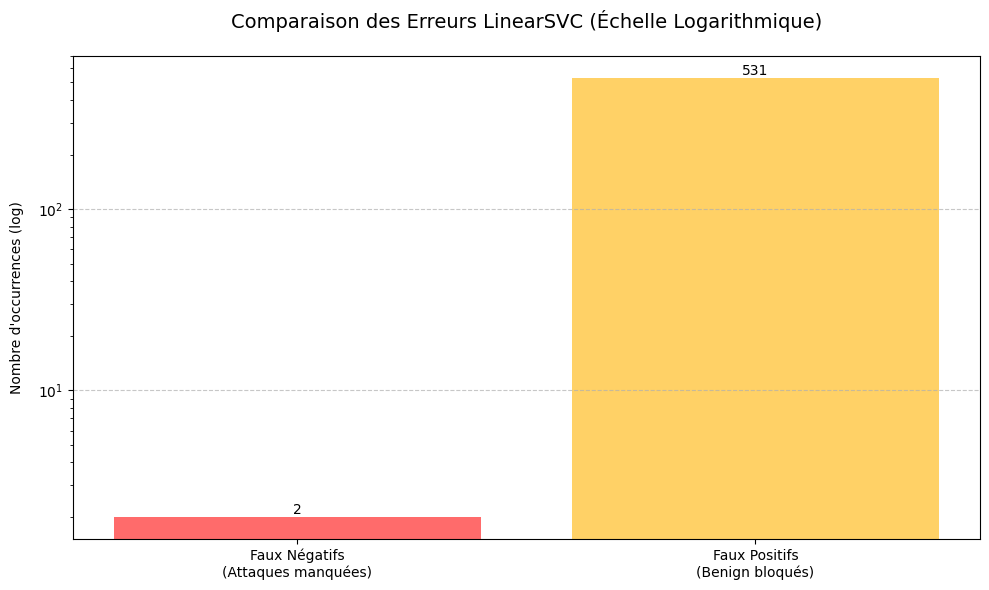

In [ ]:
# Comparaison FN vs FP
plt.figure(figsize=(10, 6))
labels = ['Faux Négatifs\n(Attaques manquées)', 'Faux Positifs\n(Benign bloqués)']
values = [FN, FP]
colors = ['#ff6b6b', '#ffd166']

bars = plt.bar(labels, values, color=colors, log=True)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom')

plt.title('Comparaison des Erreurs LinearSVC (Échelle Logarithmique)', pad=20, fontsize=14)
plt.ylabel('Nombre d\'occurrences (log)', labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("FN-vs-FP-linearsvc.png")
plt.show()